<h1 style="text-align: center;">Physical AI의 Vision-LLM 융합 시청각 멀티모달 시스템</h1>

<br><br>

<div style="text-align: right; color: gray; font-style: italic;">
강사 김규래&emsp;<br>
kkr.kyurae.kim@gmail.com&emsp;
</div><br>

---
---

## 3. 딥러닝 기초 및 GPU 가속

딥러닝(Deep Learning, DL)이란?
"사람의 뇌 신경망을 본떠 만든 인공신경망을 사용해 복잡한 데이터를 학습하는 기술"

인공신경망 (Artificial Neural Network, ANN):
* 인간의 뇌 신경세포(뉴런) 구조를 본떠 만든 학습 모델
* 입력층 (Input Layer), 은닉층 (Hidden Layer), 출력층 (Output Layer)
* 퍼셉트론 (Perceptron)이라는 인공 뉴런을 최소 단위로 사용

---

### A. 퍼셉트론의 구현

#### $1)$ 퍼셉트론의 구조와 개념

퍼셉트론(Perceptron)은 복수의 입력을 받아 각각의 가중치를 곱하고, 여기에 편향을 더해 최종 출력을 만드는 과정이자 인경신공망의 최소 단위입니다. 이번 구현에서는 가장 직관적이고 이해하기 형태인 2개의 입력을 사용하는 퍼셉트론을 살펴봅시다.
* 입력 (input): 모델이 받아들이는 외부의 데이터
* 가중치 (weight): 각 입력이 결과에 미치는 중요도나 영향력을 조절하는 계수
* 가중합: 입력에 각각의 가중치를 곱한 값의 총합
* 편향 (bias): 모델이 얼마나 쉽게 활성화될지(1을 출력할지) 기준을 조절하는 상수

$$
\text{입력: (} x_1 \text{, } x_2 \text{), \hspace{8pt} 가중치: (} w_1 \text{, } w_2 \text{), \hspace{8pt} 가중치: (} b \text{), \hspace{8pt} 출력: (} y \text{)}
$$

#### $2)$ 퍼셉트론의 연산 과정

1. 입력을 받아 입력의 가중합을 구합니다.
$$
w_1x_1 + w_2x_2
$$
2. 구한 가중합에 편향을 더하여 결과 $z$를 계산합니다.
$$
z \hspace{4pt} = \hspace{4pt} w_1x_1 + w_2x_2 + b
$$
3. 최종 산출된 $z$ 값을 사용하여 최종 출력인 $y$ 값으로 변환하기 위하여 활성화 함수 (Activation Function)을 적용합니다 ($y = f(z)$). 다양한 종류의 활성화 함수들이 있지만, 가장 기본적인 계단 함수 (Step Function)을 사용합시다.
$$
y \hspace{5pt} = \hspace{5pt}
\begin{cases}
0 \text{, \hspace{8pt}} z \ge 0\\
1 \text{, \hspace{8pt}} z < 0
\end{cases}
$$

#### $3)$ 퍼셉트론을 활용한 논리회로 구현

수식으로 살펴본 퍼셉트론의 구조와 연산 과정을 바탕으로, Python의 강력한 연산 라이브러리인 `NumPy`를 이용해 실제 코드로 구현합니다.

앞서 정의한 2개의 입력과 편향을 활용하여 논리 회로 중 가장 기초적인 AND 게이트를 퍼셉트론으로 구현하여 결과를 확인해봅시다.

우선 `NumPy` import가 필수입니다.

In [2]:
import numpy as np

논리회로 구현에 사용할 활성화 함수인 step function도 정의합시다.

In [3]:
def step_function(z_):
    if z_ >= 0:
        return 1
    return 0

In [4]:
print(step_function(-1.8))
print(step_function(-100000))
print(step_function(0.0))
print(step_function(2.1))
print(step_function(9999))

0
0
1
1
1


퍼셉트론을 활용한 AND 게이트 구현:

In [5]:
def AND_(x1, x2):
    w1, w2 = 0.5, 0.5  # 가중치 (weight)
    b = -0.7           # 편향 (bias)

    # 가중합과 편향 연산
    z = w1 * x1 + w2 * x2 + b

    # 활성화 함수 적용 (step function)
    y = step_function(z)

    # 최종 출력 반환
    return y

# AND 게이트 예시 실행 결과 확인
print(f"AND(0,0) :  {AND_(0, 0)}")  # 출력: 0
print(f"AND(1,0) :  {AND_(1, 0)}")  # 출력: 0
print(f"AND(0,1) :  {AND_(0, 1)}")  # 출력: 0
print(f"AND(1,1) :  {AND_(1, 1)}")  # 출력: 1

AND(0,0) :  0
AND(1,0) :  0
AND(0,1) :  0
AND(1,1) :  1


동일한 코드를 `NumPy`의 함수를 활용해 다시 구현해봅시다.

In [6]:
def AND(x1, x2):
    x = np.array([x1, x2])    # 입력(input)을 NumPy 배열로 정의
    w = np.array([0.5, 0.5])  # 가중치(weight)를 NumPy 배열로 정의
    b = -0.7                  # 편향(bias)

    # 가중합과 편향 연산
    z = np.sum(x * w) + b

    # 활성화 함수 적용 (step function)
    y = step_function(z)

    # 최종 출력 반환
    return y

# AND 게이트 예시 실행 결과 확인
print(f"AND(0,0) :  {AND(0, 0)}")  # 출력: 0
print(f"AND(1,0) :  {AND(1, 0)}")  # 출력: 0
print(f"AND(0,1) :  {AND(0, 1)}")  # 출력: 0
print(f"AND(1,1) :  {AND(1, 1)}")  # 출력: 1

AND(0,0) :  0
AND(1,0) :  0
AND(0,1) :  0
AND(1,1) :  1


이제 위와 같은 방식으로 OR, NAND, NOR, XOR을 순서대로 퍼셉트론을 활용하여 구현해봅시다.

In [7]:
# TODO: OR 게이트 구현

# def OR(x1, x2):
#     pass
def OR(x1, x2):
    x = np.array([x1, x2])
    w = np.array([0.5, 0.5])
    b = -0.2

    z = np.sum(x * w) + b
    y = step_function(z)

    return y

print(f"OR(0,0) :  {OR(0, 0)}")  # 출력: 0
print(f"OR(1,0) :  {OR(1, 0)}")  # 출력: 1
print(f"OR(0,1) :  {OR(0, 1)}")  # 출력: 1
print(f"OR(1,1) :  {OR(1, 1)}")  # 출력: 1

OR(0,0) :  0
OR(1,0) :  1
OR(0,1) :  1
OR(1,1) :  1


In [8]:
# TODO: NAND 게이트 구현

# def NAND(x1, x2):
#     pass
def NAND(x1, x2):
    x = np.array([x1, x2])
    w = np.array([-0.5, -0.5])
    b = 0.7

    z = np.sum(x * w) + b
    y = step_function(z)

    return y

print(f"NAND(0,0) :  {NAND(0, 0)}")  # 출력: 1
print(f"NAND(1,0) :  {NAND(1, 0)}")  # 출력: 1
print(f"NAND(0,1) :  {NAND(0, 1)}")  # 출력: 1
print(f"NAND(1,1) :  {NAND(1, 1)}")  # 출력: 0

NAND(0,0) :  1
NAND(1,0) :  1
NAND(0,1) :  1
NAND(1,1) :  0


In [9]:
# TODO: NOR 게이트 구현

# def NOR(x1, x2):
#     pass
def NOR(x1, x2):
    x = np.array([x1, x2])
    w = np.array([-0.5, -0.5])
    b = 0.2

    z = np.sum(x * w) + b
    y = step_function(z)

    return y

print(f"NOR(0,0) :  {NOR(0, 0)}")  # 출력: 1
print(f"NOR(1,0) :  {NOR(1, 0)}")  # 출력: 0
print(f"NOR(0,1) :  {NOR(0, 1)}")  # 출력: 0
print(f"NOR(1,1) :  {NOR(1, 1)}")  # 출력: 0

NOR(0,0) :  1
NOR(1,0) :  0
NOR(0,1) :  0
NOR(1,1) :  0


In [10]:
# TODO: XOR 게이트 구현

def XOR(x1, x2):
    pass

print(f"XOR(0,0) :  {XOR(0, 0)}")  # 출력: 0
print(f"XOR(1,0) :  {XOR(1, 0)}")  # 출력: 1
print(f"XOR(0,1) :  {XOR(0, 1)}")  # 출력: 1
print(f"XOR(1,1) :  {XOR(1, 1)}")  # 출력: 0

XOR(0,0) :  None
XOR(1,0) :  None
XOR(0,1) :  None
XOR(1,1) :  None


논리회로 결과 비교:

In [11]:
def print_gate_results():
    gates = ["AND", "OR", "NAND", "NOR", "XOR"]
    inputs = [(0, 0), (1, 0), (0, 1), (1, 1)]

    header = "".join(f"{name:>{len(name)+2}s}" for name in gates)
    print(f"x1 x2 |{header}")
    print("-" * (7 + sum(len(name) + 2 for name in gates)))

    for x1, x2 in inputs:
        outputs = (AND(x1,x2), OR(x1,x2), NAND(x1,x2), NOR(x1,x2), XOR(x1,x2))

        row = "".join(f"{str(v):>{len(name)+2}s}"
                      if v is not None
                      else f"{'-':>{len(name)+2}s}"
                      for v, name in zip(outputs, gates))

        print(f"{x1:2d} {x2:2d} |{row}")

print_gate_results()

x1 x2 |  AND  OR  NAND  NOR  XOR
--------------------------------
 0  0 |    0   0     1    1    -
 1  0 |    0   1     1    0    -
 0  1 |    0   1     1    0    -
 1  1 |    1   1     0    0    -


---

### B. 다층 퍼셉트론의 구현

#### 단층 vs. 다층 인공신경망 구조

단층 퍼셉트론 (Single-Layer Perceptron, SLP)
* “입력층 – 출력층”만 존재
* 선형 분리 문제만 해결 가능

다층 퍼셉트론 (Multi-Layer Perceptron, MLP)
* “입력층 – 은닉층 – 출력층” 존재 (하나 이상의 은닉층)
* 비선형 분리 문제 해결 가능

슬라이드에서 확인했듯이, XOR 논리회로는 선형적으로 분리할 수 없는 비선형 문제에 해당합니다.

따라서 이를 해결하기 위해서는 비선형 분리가 가능한 다층 퍼셉트론(MLP) 접근법이 필요하며,
이를 위해 앞서 실습한 단층 구조에 '은닉층(Hidden Layer)'을 추가해야 합니다.

In [12]:
def XOR_(x1, x2):
    # ------------- 입력층 -------------
    x = np.array([x1, x2])

    # ------------- 은닉층 -------------
    w1 = np.array([-0.5, -0.5])
    b1 = 0.7
    z1 = np.sum(x * w1) + b1
    y1 = step_function(z1)

    w2 = np.array([0.5, 0.5])
    b2 = -0.2
    z2 = np.sum(x * w2) + b2
    y2 = step_function(z2)

    # ---------- 은닉층 결과 ------------
    hidden_result = np.array([y1, y2])

    # ---------- 출력층 입력 ------------
    x_output_layer = hidden_result

    # ------------- 출력층 -------------
    w3 = np.array([0.5, 0.5])
    b3 = -0.7
    z3 = np.sum(x_output_layer * w3) + b3
    y = step_function(z3)

    return y

print(f"XOR(0,0) :  {XOR_(0, 0)}")  # 출력: 0
print(f"XOR(1,0) :  {XOR_(1, 0)}")  # 출력: 1
print(f"XOR(0,1) :  {XOR_(0, 1)}")  # 출력: 1
print(f"XOR(1,1) :  {XOR_(1, 1)}")  # 출력: 0

XOR(0,0) :  0
XOR(1,0) :  1
XOR(0,1) :  1
XOR(1,1) :  0


위 코드에서 볼 수 있듯이, XOR 논리회로는 "`AND(NAND(x1,x2), OR(x1,x2))`"입니다.

그러므로, 이전에 정의한 `AND()`, `NAND()`, `OR()` 함수를 사용하여 위의 `XOR()` 함수를 간소화할 수 있습니다.

In [13]:
# XOR(x1,x2) = AND(NAND(x1,x2), OR(x1,x2))
def XOR(x1, x2):
    s1 = NAND(x1, x2)  # 은닉층 노드 1
    s2 = OR(x1, x2)    # 은닉층 노드 2
    y = AND(s1, s2)    # 출력층

    return y

print(f"XOR(0,0) :  {XOR(0, 0)}")  # 출력: 0
print(f"XOR(1,0) :  {XOR(1, 0)}")  # 출력: 1
print(f"XOR(0,1) :  {XOR(0, 1)}")  # 출력: 1
print(f"XOR(1,1) :  {XOR(1, 1)}")  # 출력: 0

XOR(0,0) :  0
XOR(1,0) :  1
XOR(0,1) :  1
XOR(1,1) :  0


논리회로 결과 비교:

In [14]:
print_gate_results()

x1 x2 |  AND  OR  NAND  NOR  XOR
--------------------------------
 0  0 |    0   0     1    1    0
 1  0 |    0   1     1    0    1
 0  1 |    0   1     1    0    1
 1  1 |    1   1     0    0    0


앞서 살펴본 바와 같이, 단층 퍼셉트론을 통해 AND, OR, NAND, NOR 논리 게이트를 성공적으로 구현할 수 있었습니다. 하지만 단층 구조로는 해결할 수 없는 비선형 분류 문제인 XOR 게이트의 경우, 은닉층을 추가한 다층 퍼셉트론 구조를 통해 해결할 수 있음을 확인했습니다.

---

### C. 활성화 함수

활성화 함수 (Activation Function) 이란?
* 다음 뉴런으로 얼마나 신호를 전달할지 결정하는 함수
* 입력 신호를 출력 신호로 변환
* 다양한 종류의 함수 존재 (Step Function, Sigmoid, ReLU 등)

#### $1)$ Step Function

$$
f(x) \hspace{5pt} = \hspace{5pt}
\begin{cases}
0 \text{, \hspace{8pt}} x \ge 0\\
1 \text{, \hspace{8pt}} x < 0
\end{cases}
$$

우선, 앞선 실습에서 정의한 계단 함수부터 살펴보도록 하겠습니다.

In [15]:
def step_function(z_):
    if z_ >= 0:
        return 1
    return 0

In [16]:
print(step_function(-1.8))
print(step_function(-100000))
print(step_function(0.0))
print(step_function(2.1))
print(step_function(9999))

0
0
1
1
1


이 같은 경우, 오직 하나의 값을 입력하여 하나의 값을 출력하는 구조입니다. 하지만, 만약 하나의 층(Layer)에 100개의 퍼셉트론이 존재한다면 활성화 함수를 매번 100번 호출해야 하는 비효율성이 발생합니다.
더 효율적인 연산을 위해 `NumPy` 라이브러리를 활용하여 하나의 층에 포함된 모든 퍼셉트론의 출력값을 하나의 배열로 묶어, 활성화 함수를 단 한 번에 일괄 적용할 수 있습니다.

In [17]:
def step(x):
    return np.array(x > 0, dtype=int)

In [18]:
print(step(np.array([-1.8, -100000, 0.0, 2.1, 9999])))

[0 0 0 1 1]


#### $2)$ Sigmoid

$$
\sigma(x) \hspace{2pt} = \hspace{2pt} \frac{1}{1+e^{-x}}
$$

이번엔 Sigmoid 함수를 동일한 방식으로 정의해봅시다.

In [19]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

#### $3)$ ReLU

$$
\mathrm{ReLU}(x) \hspace{2pt} = \hspace{2pt} \max(0,x)
$$

마찬가지로 ReLU 함수도 정의할 수 있습니다.

In [20]:
def relu(x):
    return np.maximum(0, x)

#### 활성화 함수 시각화

이제 정의한 세 활성화 함수를 그래프로 확인해볼까요?

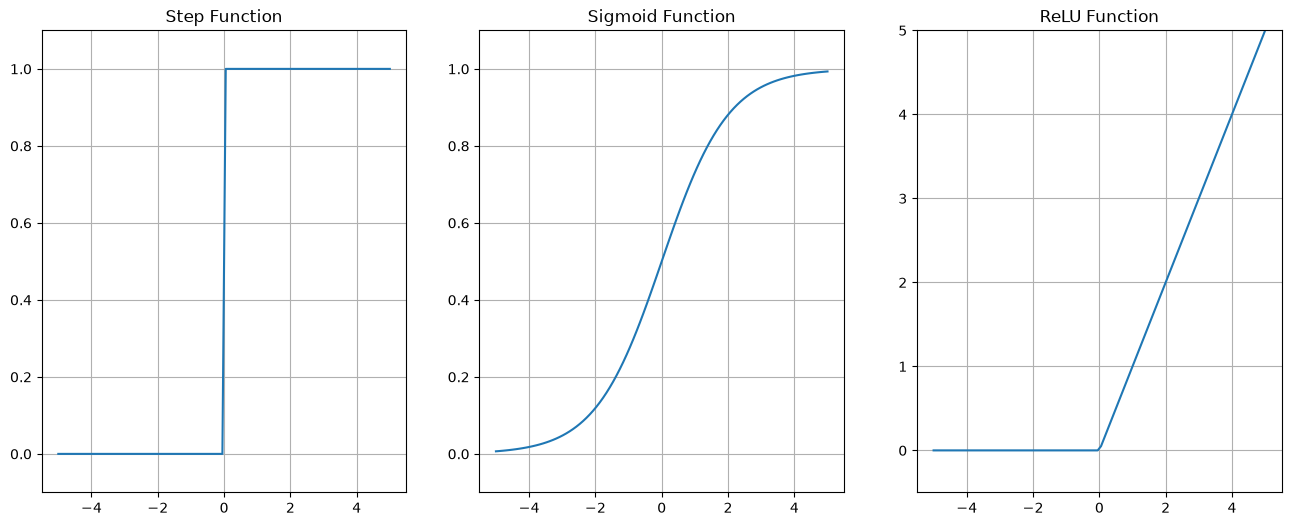

In [21]:
import matplotlib.pyplot as plt

# 입력값 범위
x = np.linspace(-5, 5, 100)

# 활성화 함수 적용 후 출력값
y_step = step(x)
y_sigmoid = sigmoid(x)
y_relu = relu(x)

plt.figure(figsize=(16,6))
plt.subplot(1,3,1), plt.plot(x, y_step), plt.title("Step Function"), plt.ylim(-0.1, 1.1), plt.grid()
plt.subplot(1,3,2), plt.plot(x, y_sigmoid), plt.title("Sigmoid Function"), plt.ylim(-0.1, 1.1), plt.grid()
plt.subplot(1,3,3), plt.plot(x, y_relu), plt.title("ReLU Function"), plt.ylim(-0.5, 5), plt.grid();

---

### D. 인공신경망 학습

학습 (Learning):
* 데이터와 정답을 비교해 가중치와 편향을 반복적으로 수정
* 오차를 최소화하는 방향으로 최적화
* 손실 함수(Loss Function)를 기준으로 학습 성능 평가
* 학습률(Learning Rate)을 조절하여 가중치 업데이트 정도 (학습 안정성) 제어

에포크 (Epoch):
* 모델을 한 번 학습하는 과정 (cycle/iteration)
* 에포크를 너무 적게 설정한 경우
  * 학습이 충분히 이루어지지 않음
  * 학습 데이터를 충분히 학습하지 못해 낮은 정확도를 보이는 과소적합(Underfitting) 발생 가능
* 에포크를 너무 많이 설정한 경우
  * 학습 데이터에 과도하게 맞춰짐
  * 학습된 데이터에만 과도하게 최적화되어 처음 보는 데이터에는 대응하지 못하는 과적합(Overfitting) 발생 가능


손실 함수 (Loss Function):
* 모델의 예측값과 실제 정답이 얼마나 다른지 계산
* 손실이 작을수록 모델의 예측이 정답과 가깝다는 의미

손실 함수의 기울기 (Gradient):
* 가중치를 증가/감소시키면 손실이 감소하는지 알 수 있는 지표
* 기울기가 하강하는 방향으로 가중치 수정
* 손실 함수의 기울기는 활성화 함수의 기울기로 계산

$$
\frac{dL}{dw} \hspace{4pt} = \hspace{4pt} \frac{dL}{dy} \hspace{2pt} × \hspace{2pt} \frac{dy}{dz} \hspace{2pt} × \hspace{2pt} \frac{dz}{dw}
$$

학습률 (Learning Rate):
* 한 번의 에포크에서 가중치를 얼마나 많이 변경할 것인지 결정
* 학습률이 너무 작은 경우
  * 학습이 매우 느림
  * 최적 가중치에 도달하는 시간이 오래 걸림
* 학습률이 너무 큰 경우
  * 적절 가중치 값을 지나칠 수 있음
  * 학습이 불안정해질 수 있음

순전파 (Forward Propagation):
* 데이터를 입력하여 다음 층으로 전달하는 과정
* 정답 예측

역전파 (Backpropagation):
* 손실 함수의 기울기를 계산하여 가중치 수정
* 손실(오차)를 거꾸로 층을 거슬러 올라가며 기울기 계산과 가중치 수정 수행

경사하강법 (Gradient Descent):
* 가중치 수정 계산법
* 손실 함수의 기울기를 사용하여 손실(오차)를 가장 낮추는 최적의 가중치를 찾는 과정

$$
w_{new} \hspace{4pt} = \hspace{4pt} w_{old} \hspace{2pt} - \hspace{2pt} \eta \frac{dL}{dw} \text{, \hspace{12pt}} \eta \text{ : 학습률}
$$

#### $1)$ 논리회로 단층 인공신경망 학습
- 앞서 논리회로 퍼셉트론을 구현할 때는 가중치와 편향을 직접 설정했으나, 
- 이번에는 데이터를 바탕으로 이 값들을 스스로 학습하는 방법과 과정을 살펴보겠습니다.

##### 1. 우선 각 논리회로의 정답을 준비합니다.

In [22]:
targets = {
    "AND" : np.array([ [0], [0], [0], [1], ], dtype=float),
    "OR"  : np.array([ [0], [1], [1], [1], ], dtype=float),
    "NAND": np.array([ [1], [1], [1], [0], ], dtype=float),
    "NOR" : np.array([ [1], [0], [0], [0], ], dtype=float),
    "XOR" : np.array([ [0], [1], [1], [0], ], dtype=float),
}

##### 2. 그 다음, 인공신경망에 입력될 학습 데이터를 준비합니다.

In [23]:
X = np.array([ [0, 0], [0, 1], [1, 0], [1, 1], ], dtype=float)

- 논리회로는 이진 분류 (Binary Classification) 문제로 볼 수 있어, 
    - 일반적으로 활성화 함수는 sigmoid와 손실 함수는 Binary Cross-Entropy를 사용합니다.

#####  3. Sigmoid 함수는 미리 정의해 두었기에 손실 함수만 새로 정의합시다.

In [24]:
def binary_cross_entropy(y_true, y_pred):
    eps = 1e-8

    loss = -np.mean(
        y_true * np.log(y_pred + eps)
        + (1 - y_true) * np.log(1 - y_pred + eps)
    )

    return loss

##### 4. 이제 활성화 함수 `sigmoid()`와 손실 함수 `binary_cross_entropy()`를 사용하여 단층 구조의 신경망을 학습시키는 함수를 정의하고, AND 게이트를 학습해봅시다.

In [25]:
def train_single_neuron(X, y, learning_rate=0.1, epochs=10000):
    # 입력 데이터 배열 크기
    sample_count, input_count = X.shape

    # 입력 데이터 배열 크기에 맞춰 가중치/편향을 초기화
    w = np.zeros((input_count, 1))
    b = np.zeros((1,))

    loss_history = []

    for epoch in range(epochs):
        # 1. 순전파
        z = X @ w + b
        y_pred = sigmoid(z)

        # 2. 손실 계산
        loss = binary_cross_entropy(y, y_pred)
        loss_history.append(loss)

        # 3. 기울기 계산
        error = y_pred - y
        w_gradient = X.T @ error / sample_count
        b_gradient = np.mean(error, axis=0)

        # 4. Weight와 Bias 업데이트
        w -= learning_rate * w_gradient
        b -= learning_rate * b_gradient

    return w, b, loss_history

In [26]:
and_weight, and_bias, and_loss = train_single_neuron(X, targets["AND"], learning_rate=0.1, epochs=10000)

and_probability = sigmoid(X @ and_weight + and_bias)
and_prediction = (and_probability >= 0.5).astype(int)

print("학습된 Weight:", and_weight)
print("학습된 Bias  :", and_bias)
print("예측 확률    :", and_probability)
print("최종 예측    :", and_prediction)

학습된 Weight: [[7.41095155]
 [7.41095155]]
학습된 Bias  : [-11.2890414]
예측 확률    : [[1.25091034e-05]
 [2.02708979e-02]
 [2.02708979e-02]
 [9.71608460e-01]]
최종 예측    : [[0]
 [0]
 [0]
 [1]]


In [27]:
training_results = {}

for gate_name, target in targets.items():
    weight, bias, loss_history = train_single_neuron(X, target, learning_rate=0.1, epochs=10000)

    probability = sigmoid(X @ weight + bias)
    prediction = (probability >= 0.5).astype(int)

    training_results[gate_name] = {
        "weight": weight,
        "bias": bias,
        "probability": probability,
        "prediction": prediction,
        "loss_history": loss_history,
    }

    print("=" * 50)
    print(f"{gate_name} 게이트")
    print("Weight       :", weight.flatten())
    print("Bias         :", bias)
    print("Probability  :", probability.flatten())
    print("Prediction   :", prediction.flatten())

AND 게이트
Weight       : [7.41095155 7.41095155]
Bias         : [-11.2890414]
Probability  : [1.25091034e-05 2.02708979e-02 2.02708979e-02 9.71608460e-01]
Prediction   : [0 0 0 1]
OR 게이트
Weight       : [8.66020366 8.66020366]
Bias         : [-3.86493825]
Probability  : [0.02053374 0.99179901 0.99179901 0.99999857]
Prediction   : [0 1 1 1]
NAND 게이트
Weight       : [-7.41095155 -7.41095155]
Bias         : [11.2890414]
Probability  : [0.99998749 0.9797291  0.9797291  0.02839154]
Prediction   : [1 1 1 0]
NOR 게이트
Weight       : [-8.66020366 -8.66020366]
Bias         : [3.86493825]
Probability  : [9.79466257e-01 8.20099159e-03 8.20099159e-03 1.43338684e-06]
Prediction   : [1 0 0 0]
XOR 게이트
Weight       : [0. 0.]
Bias         : [0.]
Probability  : [0.5 0.5 0.5 0.5]
Prediction   : [1 1 1 1]


학습 결과는 아래와 같아야 합니다.
* AND
  * Weight: 양수, 양수
  * Bias: 절댓값이 큰 음수
  * Prediction: [0, 0, 0, 1]
* OR
  * Weight: 양수, 양수
  * Bias: AND보다 절댓값이 작은 음수
  * Prediction: [0, 1, 1, 1]
* NAND
  * Weight: 음수, 음수
  * Bias: 큰 양수
  * Prediction: [1, 1, 1, 0]
* NOR
  * Weight: 음수, 음수
  * Bias: NAND보다 작은 양수
  * Prediction: [1, 0, 0, 0]
* XOR (단일 뉴런으로 학습되지 않는다)
  * Weight: 0에 가까운 값
  * Bias: 0에 가까운 값
  * Probability: 약 [0.5, 0.5, 0.5, 0.5]

In [28]:
for gate_name, target in targets.items():
    prediction = training_results[gate_name]["prediction"]
    accuracy = np.mean(prediction == target)

    print(f"{gate_name} accuracy: {accuracy:.2f}")

AND accuracy: 1.00
OR accuracy: 1.00
NAND accuracy: 1.00
NOR accuracy: 1.00
XOR accuracy: 0.50


##### XOR 정확도가 약 50%라는 것은 단일 뉴런이 XOR 규칙을 학습하지 못했다는 의미이다.

##### 이번에는 epoch가 진행됨에 따라 손실이 어떻게 변화하는지 그래프로 시각화해 봅시다.

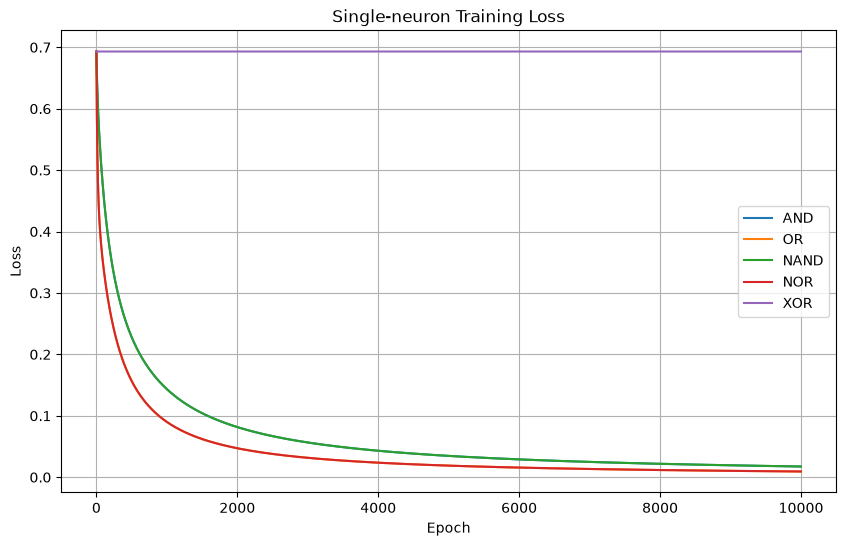

In [29]:
plt.figure(figsize=(10, 6))

for gate_name in targets:
    loss_history = training_results[gate_name]["loss_history"]
    plt.plot(loss_history, label=gate_name)

plt.xlabel("Epoch"), plt.ylabel("Loss"), plt.title("Single-neuron Training Loss"), plt.grid(), plt.legend();

* AND, OR, NAND, NOR 손실은 학습이 진행되면서 감소한다.
* XOR 손실은 충분히 감소하지 않는다.
* 모델 구조가 문제를 해결할 수 없으면 Epoch를 증가시켜도 해결되지 않는다.
* 데이터가 충분하고 Epoch가 많더라도 모델 구조 자체가 문제에 적합하지 않으면 학습할 수 없다.

#### $2)$ 논리회로 다층 인공신경망 학습

- XOR을 학습하기 위해 다음 구조를 사용합니다.
    - 입력층: 2개
    - 은닉층: 4개 뉴런
    - 출력층: 1개 뉴런
- 파라미터는 다음과 같습니다.
    - W1: 입력층 → 은닉층 가중치
    - b1: 은닉층 편향
    - W2: 은닉층 → 출력층 가중치
    - b2: 출력층 편향

- 파라미터 크기:
    - X:  (4, 2)
    - W1: (2, 4)
    - b1: (1, 4)
    
    - Y1: (4, 4)
     
    - W2: (4, 1)
    - b2: (1, 1)
     
    - 출력: (4, 1)

이제 다층 인공신경망 학습 함수를 정의합시다.

In [30]:
def train_multi_neuron(X, y, hidden_size=4, learning_rate=1.0, epochs=20000, seed=42):
    sample_count, input_count = X.shape
    output_size = 1

    rng = np.random.default_rng(seed)

    W1 = rng.normal(loc=0.0, scale=1.0, size=(input_count, hidden_size))
    b1 = np.zeros((1, hidden_size))
    W2 = rng.normal(loc=0.0, scale=1.0, size=(hidden_size, output_size))
    b2 = np.zeros((1, output_size))

    loss_history = []

    for epoch in range(epochs):
        # 1. 순전파: 입력층 → 은닉층
        Z1 = X @ W1 + b1
        Y1 = sigmoid(Z1)

        # 2. 순전파: 은닉층 → 출력층
        Z2 = Y1 @ W2 + b2
        y_pred = sigmoid(Z2)

        # 3. 손실 계산
        loss = binary_cross_entropy(y, y_pred)
        loss_history.append(loss)

        # 4. 출력층 기울기
        dZ2 = (y_pred - y) / sample_count
        dW2 = Y1.T @ dZ2
        db2 = np.sum(dZ2, axis=0, keepdims=True)

        # 5. 은닉층 기울기
        dY1 = dZ2 @ W2.T
        dZ1 = dY1 * Y1 * (1 - Y1)
        dW1 = X.T @ dZ1
        db1 = np.sum(dZ1, axis=0, keepdims=True)

        # 6. 파라미터 업데이트
        W1 -= learning_rate * dW1
        b1 -= learning_rate * db1
        W2 -= learning_rate * dW2
        b2 -= learning_rate * db2

        if epoch % 2000 == 0:
            print(f"Epoch {epoch:5d}, " f"Loss: {loss:.6f}")

    parameters = {
        "W1": W1,
        "b1": b1,
        "W2": W2,
        "b2": b2,
    }

    return parameters, loss_history

이제 정의한 함수를 사용하여 학습을 실행합니다.

In [31]:
xor_parameters, xor_loss_history = train_multi_neuron(
    X,
    targets["XOR"],
    hidden_size=4,
    learning_rate=1.0,
    epochs=20000,
    seed=42,
)

Epoch     0, Loss: 0.756798
Epoch  2000, Loss: 0.003915
Epoch  4000, Loss: 0.001472
Epoch  6000, Loss: 0.000882
Epoch  8000, Loss: 0.000624
Epoch 10000, Loss: 0.000481
Epoch 12000, Loss: 0.000390
Epoch 14000, Loss: 0.000328
Epoch 16000, Loss: 0.000283
Epoch 18000, Loss: 0.000248


학습 결과를 확인해볼까요?

In [32]:
W1 = xor_parameters["W1"]
b1 = xor_parameters["b1"]
W2 = xor_parameters["W2"]
b2 = xor_parameters["b2"]

hidden_output = sigmoid(X @ W1 + b1)
xor_probability = sigmoid(hidden_output @ W2 + b2)
xor_prediction = (xor_probability >= 0.5).astype(int)

print("입력:")
print(X.astype(int))
print("예측 확률:")
print(xor_probability)
print("최종 예측:")
print(xor_prediction)

입력:
[[0 0]
 [0 1]
 [1 0]
 [1 1]]
예측 확률:
[[1.25406697e-04]
 [9.99735996e-01]
 [9.99819922e-01]
 [3.15292185e-04]]
최종 예측:
[[0]
 [1]
 [1]
 [0]]


학습된 Weight와 Bias도 확인해봅시다.

In [33]:
print("W1:")
print(W1)
print("b1:")
print(b1)
print("W2:")
print(W2)
print("b2:")
print(b2)

W1:
[[ 5.65783191 -6.78064266  6.7867797  -3.98964783]
 [-7.52169895 -7.24629988 -4.58884642 -3.19885443]]
b1:
[[-2.65787343  2.65529546  1.80758692  5.34531148]]
W2:
[[ 12.18483752]
 [-10.92473602]
 [-10.9515956 ]
 [  8.46805598]]
b2:
[[1.40572112]]


마지막으로, XOR 인공신경망의 손실 변화를 그래프로 확인해봅시다.

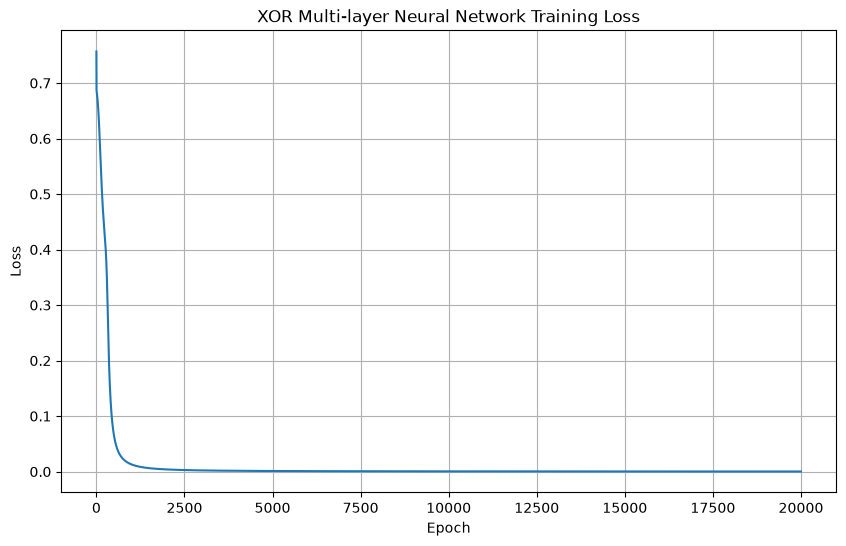

In [34]:
plt.figure(figsize=(10, 6))
plt.plot(xor_loss_history)
plt.xlabel("Epoch"), plt.ylabel("Loss"), plt.title("XOR Multi-layer Neural Network Training Loss"), plt.grid();

이와 같이 은닉층을 활용한 다층 인공신경망을 학습시켜 비선형적인 분류 문제를 해결할 수 있음을 확인했습니다.

---

### E. Convolutional Neural Network (CNN) 개요

합성곱 신경망 (CNN)이란?
* 이미지처럼 공간적인 구조를 가진 데이터를 처리하기 위해 설계된 신경망
* 이미지를 2차원 또는 3차원 형태로 유지하면서 주변 픽셀 사이의 패턴을 추출
* 커널(Kernel)을 활용한 합성곱(Convolution) 연산을 통해 이미지의 특징을 추출
* 합성곱의 결과로 특징 맵 (Feature Map)을 생성
* 풀링(Pooling)을 통해 중요한 특징은 유지하면서 데이터 크기를 줄여 연산 효율을 높임
* 추출된 특징을 바탕으로 이미지 분류, 객체 탐지, 얼굴 인식 등 다양한 컴퓨터 비전 분야에서 활용됨

특징 맵 (Feature Map):
* 합성곱(Convolution) 연산의 결과로 생성되는 특징 표현
* 입력 이미지의 특정 특징을 강조하여 나타냄
* 하나의 Kernel당 하나의 Feature Map이 생성됨
* 생성된 Feature Map은 다음 층의 입력으로 사용되어 더 복잡한 특징을 학습

특징 맵 (Feature Map)의 값:
* 해당 위치에서 Filter가 찾는 패턴이 얼마나 강하게 나타나는지를 의미
  * 큰 양수  →  Filter 패턴과 유사한 특징이 강하게 존재
  * 0에 가까운 값  →  특징이 거의 없음
  * 큰 음수  →  Filter 패턴과 반대 방향의 특징이 존재
* CNN에서는 합성곱 결과에 ReLU를 적용하는 경우가 많음
  * 음수 값은 0으로 변환, 양수 값은 유지

####  Feature Map 생성

이전 세션에서 다룬 이미지 전처리 과정인 필터링(Filtering)과 마찬가지로, CNN에서도 이미지 위에서 격자 형태의 커널(Kernel)을 움직이며 합성곱을 계산합니다. 그 결과, 이미지의 핵심 특징이 담긴 Feature Map이 생성됩니다.

연산의 첫 과정은 기존 필터링과 동일합니다. 원하는 특징을 추출하기 위해 적절한 크기의 커널을 정의한 뒤, 이미지 위를 이동하며 합성곱을 계산합니다. 그 이후 CNN에서는 활성화 함수인 ReLU를 적용하여, 원치 않는 특성(음수 값)은 0으로 처리하고 유의미한 특성(양수 값)은 그대로 유지합니다.

우선 필수 라이브러리를 import 합니다. `NumPy`와 `matplotlib`는 위 과정에서 이미 import 했으니, 이미지를 불러오기 위한 `OpenCV` 라이브러리를 import 합시다.

In [35]:
# %pip install opencv-python

In [36]:
import cv2

Feature Map 실습을 위한 이미지를 불러옵니다.

(np.float64(-0.5), np.float64(959.5), np.float64(719.5), np.float64(-0.5))

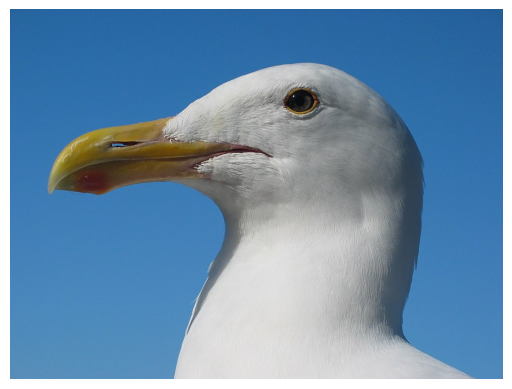

In [37]:
img_path = "src/images/seagull.jpg"

img_bgr = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.axis("off")

오늘 추출할 특징은 edge이므로 색상 정보는 불필요합니다. 그러므로 이미지를 흑백으로 변환합시다.

(np.float64(-0.5), np.float64(959.5), np.float64(719.5), np.float64(-0.5))

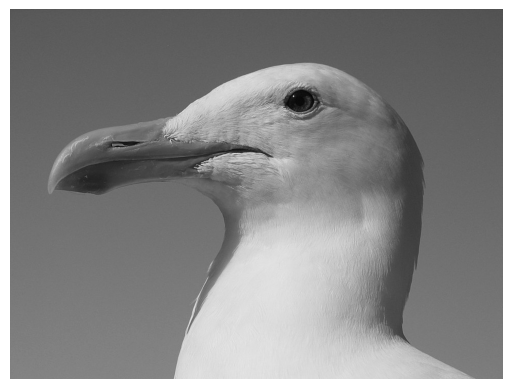

In [38]:
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

plt.imshow(img_gray, cmap="gray")
plt.axis("off")

이제, 2차원 이미지에 하나의 CNN 필터를 적용하는 함수를 정의합니다.

필터를 적용하게 되면 입력 이미지의 크기, 커널의 크기, stride와 padding 값에 따라 최종 출력 이미지의 크기가 결정됩니다.

$H: \hspace{4pt}$ 입력 이미지 높이
$W: \hspace{4pt}$ 입력 이미지 너비
$P: \hspace{4pt}$ Padding 픽셀 값
$K: \hspace{4pt}$ 커널 크기
$S: \hspace{4pt}$ Stride 픽셀 값

$$
height \hspace{4pt} = \hspace{4pt}
\lfloor \frac{H+2P-K}{S} \rfloor \hspace{2pt} + \hspace{2pt} 1
$$

$$
width \hspace{4pt} = \hspace{4pt}
\lfloor \frac{W+2P-K}{S} \rfloor \hspace{2pt} + \hspace{2pt} 1
$$

In [39]:
def convolution2d(image, kernel, bias=0.0, stride=1, padding=0):
    """
    2차원 이미지에 하나의 CNN 필터를 적용.

    Parameters
    ----------
    image   : np.ndarray    :   입력 이미지, shape = (height, width)
    kernel  : np.ndarray    :   CNN 필터, shape = (kernel_height, kernel_width)
    bias    : float         :   필터 출력에 더할 편향
    stride  : int           :   필터가 이동하는 간격
    padding : int           :   입력 이미지 가장자리에 추가할 픽셀의 개수

    Returns
    -------
    output  : np.ndarray    : 편향까지 적용된 convolution 결과
    """

    image_height, image_width = image.shape
    kernel_height, kernel_width = kernel.shape

    # 이미지 가장자리에 zero padding 적용
    padded_image = np.pad(
        image,
        ((padding, padding), (padding, padding)),
        mode="constant",
        constant_values=0
    )

    # (H, W: 입력 이미지 높이 및 너비, P: Padding 픽셀 값, S: Stride 픽셀 값)
    # Convolution 출력 이미지 높이 = floor((H + 2P - K) / S) + 1
    output_height = (padded_image.shape[0] - kernel_height) // stride + 1

    # Convolution 출력 이미지 너비 = floor((W + 2P - K) / S) + 1
    output_width = (padded_image.shape[1] - kernel_width) // stride + 1

    # 계산한 크기로 출력 이미지 준비
    output = np.zeros((output_height, output_width), dtype=np.float32)

    # 커널을 움직이며 필터 적용
    for output_y in range(output_height):
        for output_x in range(output_width):
            # 커널을 적용할 이미지 영역의 좌측상단
            start_y = output_y * stride
            start_x = output_x * stride

            # 커널을 적용할 이미지 영역을 crop
            image_region = padded_image[
                start_y:start_y + kernel_height,
                start_x:start_x + kernel_width
            ]

            # 필터를 적용하여 가중합 계산
            weighted_sum = np.sum(image_region * kernel)

            # 편향 적용
            output[output_y, output_x] = weighted_sum + bias

    return output

이제 CNN의 가중치와 편향을 구해야 합니다. 하지만 이번 실습에서는 모델을 직접 학습시키는 대신, 커널을 통해 Edge를 추출한 Feature Map을 생성하고 확인해 보는 것이 목적이므로 가중치와 편향을 직접 설정하겠습니다.

CNN에서의 가중치와 편향이 무엇을 의미할까요?
* CNN의 가중치: 적용할 필터(커널) 각 칸의 값
* CNN의 편향: 약한 특징을 무시하거나 증폭시키기 위한 값

우선 CNN의 가중치를 설정합시다.

이전 세션의 Sobel Filter 과정에서 배운 것처럼, 가로와 세로 방향의 edge를 검출하기 위한 커널을 각각 정의해봅시다.

In [40]:
# x축 방향 edge (세로 선) 검출 필터
dx_edge_filter = np.array(
    [
        [-1, 0, 1],
        [-1, 0, 1],
        [-1, 0, 1]
    ],
    dtype=np.float32
)

# y축 방향 edge (가로 선) 검출 필터
dy_edge_filter = np.array(
    [
        [-1, -1, -1],
        [0, 0, 0],
        [1, 1, 1]
    ],
    dtype=np.float32
)

그 다음, CNN의 편향도 설정해봅시다.

가로/세로 선 검출 시, 너무 약한 특징은 무시하도록 합시다.

In [41]:
# 너무 약한 특징 (0.2 이하)은 무시
dx_bias = -0.2
dy_bias = -0.2

최종적으로, 이미지에 가중치(필터)와 편향을 적용하는 `convolution2d()` 함수와 앞서 정의한 활성화 함수(ReLU)를 적용하는 `relu()` 함수를 사용하여 Feature Map을 생성합니다.

In [42]:
# 딥러닝 모델에서 더 안정적인 계산을 위해 이미지를 실수(float32)로 변환
input_image = img_gray.astype(np.float32) / 255.

# 가중치와 편향을 적용하여 세로 edge를 검출한 Feature Map 생성
vertical_output = convolution2d(
    image=input_image,
    kernel=dx_edge_filter,
    bias=dx_bias,
    stride=1,
    padding=1
)

# 가중치와 편향을 적용하여 가로 edge를 검출한 Feature Map 생성
horizontal_output = convolution2d(
    image=input_image,
    kernel=dy_edge_filter,
    bias=dy_bias,
    stride=1,
    padding=1
)

# 활성화 함수 (ReLU) 적용
vertical_feature_map = relu(vertical_output)
horizontal_feature_map = relu(horizontal_output)

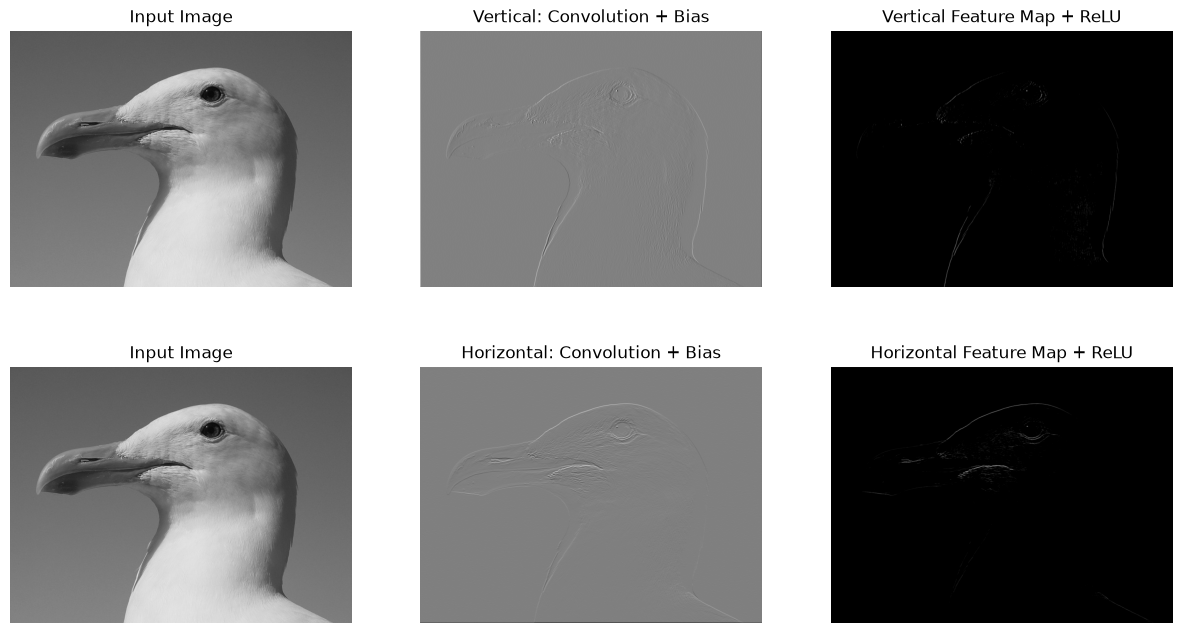

In [43]:
plt.figure(figsize=(15,8))

plt.subplot(2,3,1), plt.imshow(input_image, cmap="gray"), plt.title("Input Image")
plt.subplot(2,3,2), plt.imshow(vertical_output, cmap="gray"), plt.title("Vertical: Convolution + Bias")
plt.subplot(2,3,3), plt.imshow(vertical_feature_map, cmap="gray"), plt.title("Vertical Feature Map + ReLU")
plt.subplot(2,3,4), plt.imshow(input_image, cmap="gray"), plt.title("Input Image")
plt.subplot(2,3,5), plt.imshow(horizontal_output, cmap="gray"), plt.title("Horizontal: Convolution + Bias")
plt.subplot(2,3,6), plt.imshow(horizontal_feature_map, cmap="gray"), plt.title("Horizontal Feature Map + ReLU")

for ax in plt.gcf().axes:
    ax.axis("off")

ReLU를 사용하면 필터가 적용된 결과에서 음수 값을 무시하게 됩니다.
가로/세로 edge 필터를 적용한 결과에서 부호(+/-)는 edge의 방향 정보를 담고 있습니다.

현재 적용한 필터를 예로 들어봅시다.

$$
\begin{bmatrix}
-1 & 0 & 1 \\
-1 & 0 & 1 \\
-1 & 0 & 1
\end{bmatrix}
$$

이와 같은 경우, 양수 결과 값은 왼쪽이 어둡고 오른쪽이 밝다는 의미입니다. 음수 결과 값은 반대로 왼쪽이 밝고 오른쪽이 어둡다는 정보를 갖고 있습니다.
ReLU 함수를 적용하면 오직 오른쪽이 왼쪽보다 급격히 밝아지는 영역만 검출하게 됩니다. 이런 결과는 손글씨 인식과 같이 정확한 획의 형태를 파악하는 경우에 유용하게 사용됩니다.

반대 방향 edge를 추출한 Feature Map도 시각화해봅시다.

In [44]:
# 딥러닝 모델에서 더 안정적인 계산을 위해 이미지를 실수(float32)로 변환
input_image = img_gray.astype(np.float32) / 255.

# 필터의 방향을 반대로 설정
dx_reverse_filter = -dx_edge_filter
dy_reverse_filter = -dy_edge_filter

# 가중치와 편향을 적용하여 세로 edge를 검출한 Feature Map 생성
vertical_reverse_output = convolution2d(
    image=input_image,
    kernel=dx_reverse_filter,
    bias=dx_bias,
    stride=1,
    padding=1
)

# 가중치와 편향을 적용하여 가로 edge를 검출한 Feature Map 생성
horizontal_reverse_output = convolution2d(
    image=input_image,
    kernel=dy_reverse_filter,
    bias=dy_bias,
    stride=1,
    padding=1
)

# 활성화 함수 (ReLU) 적용
vertical_reverse_feature_map = relu(vertical_reverse_output)
horizontal_reverse_feature_map = relu(horizontal_reverse_output)

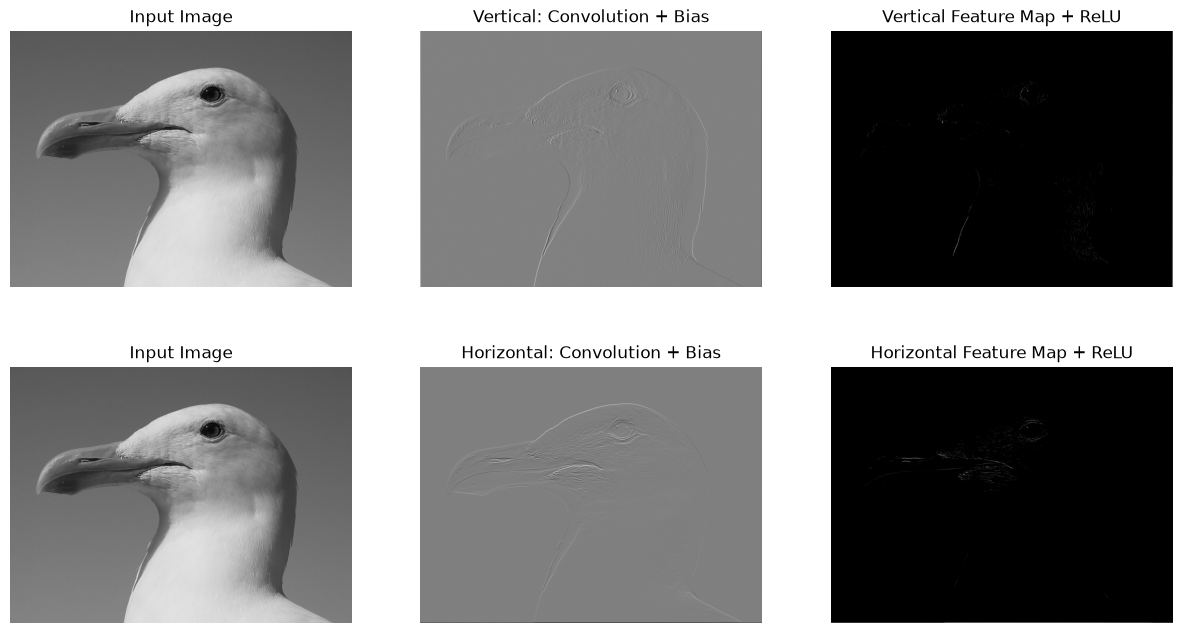

In [45]:
plt.figure(figsize=(15,8))

plt.subplot(2,3,1), plt.imshow(input_image, cmap="gray"), plt.title("Input Image")
plt.subplot(2,3,2), plt.imshow(vertical_output, cmap="gray"), plt.title("Vertical: Convolution + Bias")
plt.subplot(2,3,3), plt.imshow(vertical_reverse_feature_map, cmap="gray"), plt.title("Vertical Feature Map + ReLU")
plt.subplot(2,3,4), plt.imshow(input_image, cmap="gray"), plt.title("Input Image")
plt.subplot(2,3,5), plt.imshow(horizontal_output, cmap="gray"), plt.title("Horizontal: Convolution + Bias")
plt.subplot(2,3,6), plt.imshow(horizontal_reverse_feature_map, cmap="gray"), plt.title("Horizontal Feature Map + ReLU")

for ax in plt.gcf().axes:
    ax.axis("off")

비교:

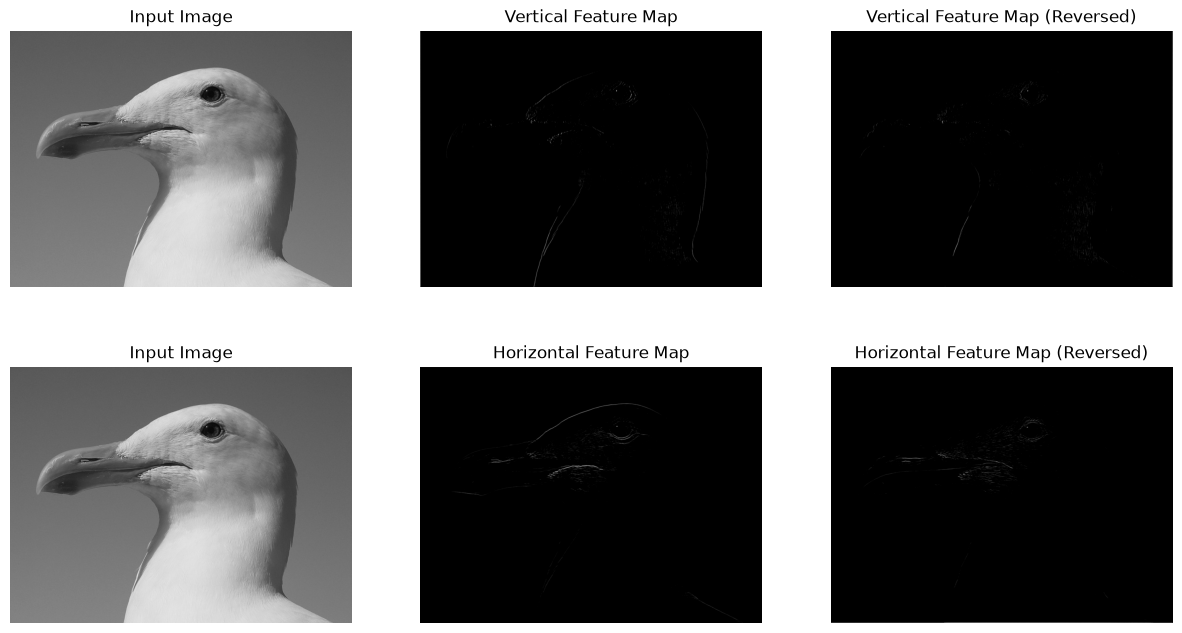

In [46]:
plt.figure(figsize=(15,8))

plt.subplot(2,3,1), plt.imshow(input_image, cmap="gray"), plt.title("Input Image")
plt.subplot(2,3,2), plt.imshow(vertical_feature_map, cmap="gray"), plt.title("Vertical Feature Map")
plt.subplot(2,3,3), plt.imshow(vertical_reverse_feature_map, cmap="gray"), plt.title("Vertical Feature Map (Reversed)")
plt.subplot(2,3,4), plt.imshow(input_image, cmap="gray"), plt.title("Input Image")
plt.subplot(2,3,5), plt.imshow(horizontal_feature_map, cmap="gray"), plt.title("Horizontal Feature Map")
plt.subplot(2,3,6), plt.imshow(horizontal_reverse_feature_map, cmap="gray"), plt.title("Horizontal Feature Map (Reversed)")

for ax in plt.gcf().axes:
    ax.axis("off")

앞선 실습에서 확인한 방법으로, Smoothing 필터와 Sharpening 필터를 적용하여 Feature Map을 생성해봅시다.

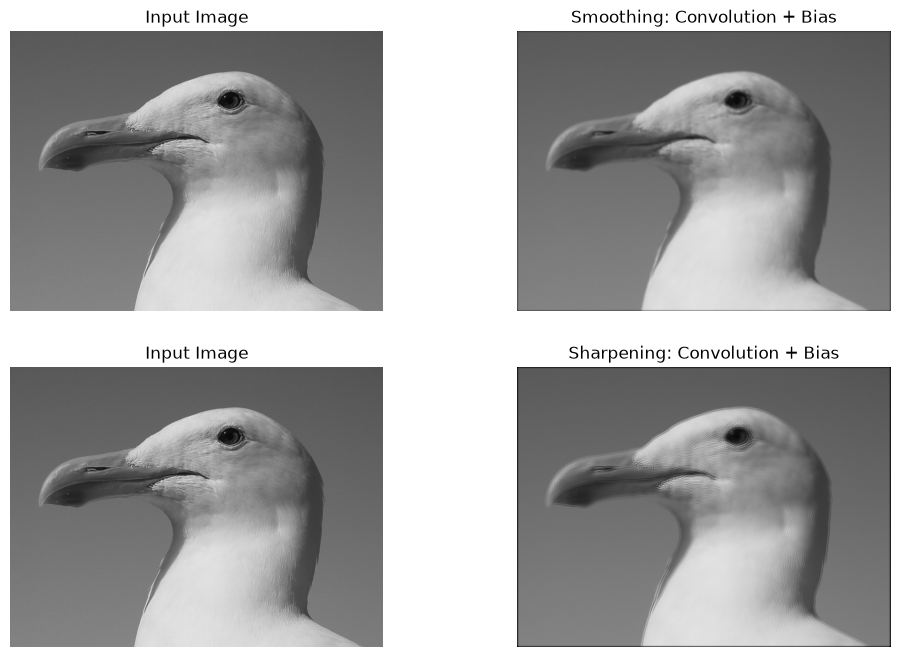

In [47]:
# TODO: Smoothing/Sharpening 필터 정의
# smoothing_filter = np.array(...)
# sharpening_filter = np.array(...)
smoothing_filter = np.array(
    [
        [0.0005, 0.0013, 0.0028, 0.0047, 0.0065, 0.0073, 0.0065, 0.0047, 0.0028, 0.0013, 0.0005],
        [0.0013, 0.0035, 0.0077, 0.0130, 0.0180, 0.0202, 0.0180, 0.0130, 0.0077, 0.0035, 0.0013],
        [0.0028, 0.0077, 0.0167, 0.0282, 0.0390, 0.0438, 0.0390, 0.0282, 0.0167, 0.0077, 0.0028],
        [0.0047, 0.0130, 0.0282, 0.0477, 0.0660, 0.0742, 0.0660, 0.0477, 0.0282, 0.0130, 0.0047],
        [0.0065, 0.0180, 0.0390, 0.0660, 0.0913, 0.1026, 0.0913, 0.0660, 0.0390, 0.0180, 0.0065],
        [0.0073, 0.0202, 0.0438, 0.0742, 0.1026, 0.1153, 0.1026, 0.0742, 0.0438, 0.0202, 0.0073],
        [0.0065, 0.0180, 0.0390, 0.0660, 0.0913, 0.1026, 0.0913, 0.0660, 0.0390, 0.0180, 0.0065],
        [0.0047, 0.0130, 0.0282, 0.0477, 0.0660, 0.0742, 0.0660, 0.0477, 0.0282, 0.0130, 0.0047],
        [0.0028, 0.0077, 0.0167, 0.0282, 0.0390, 0.0438, 0.0390, 0.0282, 0.0167, 0.0077, 0.0028],
        [0.0013, 0.0035, 0.0077, 0.0130, 0.0180, 0.0202, 0.0180, 0.0130, 0.0077, 0.0035, 0.0013],
        [0.0005, 0.0013, 0.0028, 0.0047, 0.0065, 0.0073, 0.0065, 0.0047, 0.0028, 0.0013, 0.0005]
    ],
    dtype=np.float32
)

sharpening_filter = np.array(
    [
        [-0.001, -0.003, -0.006, -0.009, -0.013, -0.015, -0.013, -0.009, -0.006, -0.003, -0.001],
        [-0.003, -0.007, -0.015, -0.026, -0.036, -0.040, -0.036, -0.026, -0.015, -0.007, -0.003],
        [-0.006, -0.015, -0.033, -0.056, -0.078, -0.088, -0.078, -0.056, -0.033, -0.015, -0.006],
        [-0.009, -0.026, -0.056, -0.095, -0.132, -0.148, -0.132, -0.095, -0.056, -0.026, -0.009],
        [-0.013, -0.036, -0.078, -0.132, -0.183, -0.205, -0.183, -0.132, -0.078, -0.036, -0.013],
        [-0.015, -0.040, -0.088, -0.148, -0.205, 3.000, -0.205, -0.148, -0.088, -0.040, -0.015],
        [-0.013, -0.036, -0.078, -0.132, -0.183, -0.205, -0.183, -0.132, -0.078, -0.036, -0.013],
        [-0.009, -0.026, -0.056, -0.095, -0.132, -0.148, -0.132, -0.095, -0.056, -0.026, -0.009],
        [-0.006, -0.015, -0.033, -0.056, -0.078, -0.088, -0.078, -0.056, -0.033, -0.015, -0.006],
        [-0.003, -0.007, -0.015, -0.026, -0.036, -0.040, -0.036, -0.026, -0.015, -0.007, -0.003],
        [-0.001, -0.003, -0.006, -0.009, -0.013, -0.015, -0.013, -0.009, -0.006, -0.003, -0.001]
    ],
    dtype=np.float32
)

# TODO: Smoothing/Sharpening 필터 정규화 (필터 정의에서 이미 정규화 하였다면 스킵)
# smoothing_filter = ...
# sharpening_filter = ...
smoothing_filter = smoothing_filter / np.sum(smoothing_filter)
sharpening_filter = sharpening_filter / np.sum(sharpening_filter)

# TODO: Smoothing/Sharpening 편향 정의
# smoothing_bias = ...
# sharpening_bias = ...
smoothing_bias = 0
sharpening_bias = 0

# TODO: convolution2d 함수를 사용하여 가중치와 편향 적용
# smoothing_output = ...
# sharpening_output = ...
smoothing_output = convolution2d(
    image=input_image,
    kernel=smoothing_filter,
    bias=smoothing_bias,
    stride=1,
    padding=5
)

sharpening_output = convolution2d(
    image=input_image,
    kernel=sharpening_filter,
    bias=sharpening_bias,
    stride=1,
    padding=5
)

# TODO: 활성화 함수 적용 (필요할 시)
# smoothing_feature_map = ...
# sharpening_feature_map = ...
smoothing_feature_map = smoothing_output
sharpening_feature_map = sharpening_output

# 결과 시각화
plt.figure(figsize=(12,8))

plt.subplot(2,2,1), plt.imshow(input_image, cmap="gray"), plt.title("Input Image")
plt.subplot(2,2,2), plt.imshow(smoothing_output, cmap="gray", vmin=0, vmax=1), plt.title("Smoothing: Convolution + Bias")
plt.subplot(2,2,3), plt.imshow(input_image, cmap="gray"), plt.title("Input Image")
plt.subplot(2,2,4), plt.imshow(sharpening_output, cmap="gray", vmin=0, vmax=1), plt.title("Sharpening: Convolution + Bias")

for ax in plt.gcf().axes:
    ax.axis("off")

---

### F. CNN 실습 – MNIST 데이터셋

실습에 앞서 필요한 라이브러리를 설치해야 합니다.

그러기 위해서는 먼저 현재 JetPack과 CUDA 버전을 확인합시다.

```bash
dpkg -l | grep nvidia-jetpack
cat /usr/local/cuda/version.json
```

JetPack 6.2.1 + CUDA 12.6 기준,
```text
torch 2.8.0
torchvision 0.23.0
cu126
```
조합을 사용할 수 있습니다.

설치:

```bash
pip install torch==2.8.0 torchvision --index-url https://pypi.jetson-ai-lab.io/jp6/cu126 --no-deps
pip uninstall torchvision
pip install torchvision==0.23.0 --index-url https://pypi.jetson-ai-lab.io/jp6/cu126 --no-deps
pip install "sympy>=1.13.3" --no-deps
```

In [48]:
# %pip install torch torchvision

In [49]:
import torch
import torchvision

print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)

PyTorch version: 2.13.0+cpu
Torchvision version: 0.28.0+cpu


위 코드가 에러 없이 실행이 되었다면 다음으로 넘어가면 됩니다.

#### $1)$ 필수 라이브러리 import

우선, 필요한 라이브러리를 전부 import 합시다.

In [50]:
import time
import random

import  torch.nn as nn
import  torch.nn.functional as F
from    torch.utils.data    import DataLoader
from    torchvision         import datasets, transforms

#### $2)$ 난수 고정

같은 코드를 반복 실행했을 때 최대한 비슷한 결과를 얻기 위해 난수 seed를 고정합니다.
결과가 완전히 동일하지 않을 수 있지만, 실습 결과의 재현성을 높일 수 있습니다.

In [51]:
seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed);

#### $3)$ MNIST 데이터셋 설치 및 불러오기

손글씨 데이터셋인 MNIST 데이터를 불러옵시다.

최초로 데이터를 불러올 경우, 지정된 경로에 설치합니다.

In [52]:
# 데이터를 불러올 때 이미지 전처리 방식 정의
# PIL 이미지 또는 NumPy 이미지를 PyTorch Tensor로 변환
# 일반적인 8비트 이미지의 픽셀값을 0~1 범위의 실수로 변환
transform = transforms.ToTensor()

# 학습 데이터 불러오기 (최초 다운로드)
train_dataset = datasets.MNIST(
    root="src/datasets",
    train=True,
    transform=transform,
    download=True,
)

# 테스트 데이터 불러오기 (최초 다운로드)
test_dataset = datasets.MNIST(
    root="src/datasets",
    train=False,
    transform=transform,
    download=True,
)

데이터셋을 설치할 `src/datasets` 폴더가 존재하는지 확인해봅시다.

만약 MNIST 데이터가 올바르게 설치되었다면, `datasets` 안에 `MNIST` 폴더가 자동으로 생성되고 그 내부에 데이터가 위치해 있을 것입니다.

아래 코드를 통해 확인해봅시다.

In [53]:
print(
    "Train data:",
    len(train_dataset)
)

print(
    "Test data:",
    len(test_dataset)
)

Train data: 60000
Test data: 10000


정상적으로 설치되었다면 학습 데이터는 60000개, 테스트 데이터는 10000개가 존재할 것입니다.

#### $4)$ MNIST 데이터 확인

설치된 MNIST 데이터를 확인해봅시다.

In [54]:
image, label = train_dataset[0]

print("Image type:", type(image))
print("Image shape:", image.shape)
print("Label:", label)
print("Minimum:", image.min().item())
print("Maximum:", image.max().item())

Image type: <class 'torch.Tensor'>
Image shape: torch.Size([1, 28, 28])
Label: 5
Minimum: 0.0
Maximum: 1.0


해당 코드의 결과는 다음과 같아야 합니다.

Image type: <class 'torch.Tensor'><br>
Image shape: torch.Size([1, 28, 28])<br>
Label: 5<br>
Minimum: 0.0<br>
Maximum: 1.0

특히, 이미지의 크기가 `1x28x28`인 것을 확인해야 합니다.

#### $5)$ MNIST 데이터 시각화

우선, 위에서 간단한 확인을 위해 선택한 `train_data[0]`을 확인해봅시다.

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

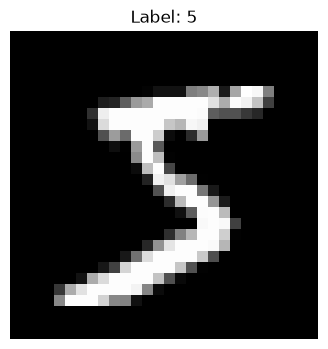

In [55]:
image_2d = image.squeeze(0)

plt.figure(figsize=(4,4))
plt.imshow(image_2d, cmap="gray"), plt.title(f"Label: {label}")
plt.axis("off")

이번에는 `train_data` 총 20개를 시각화해 봅시다.

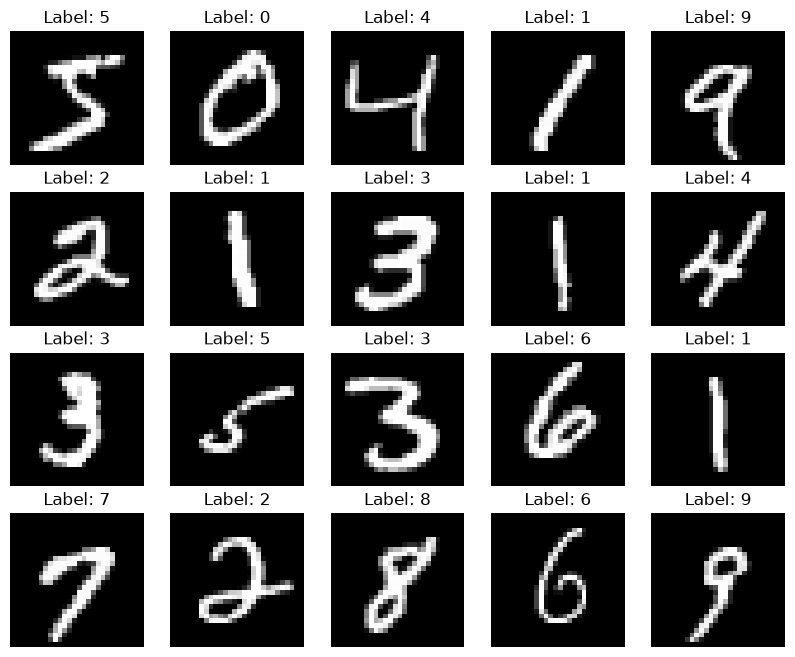

In [56]:
plt.figure(figsize=(10,8))

for index in range(20):
    image, label = train_dataset[index]
    plt.subplot(4,5,index+1), plt.imshow(image.squeeze(0), cmap="gray"), plt.title(f"Label: {label}")
    plt.axis("off")

여기서 알 수 있는 사실은:
* 같은 숫자라도 사람마다 쓰는 방식이 다르다.
* 숫자의 위치가 조금씩 다르다.
* 획의 굵기와 기울기가 다르다.
* 일부 숫자는 다른 숫자와 비슷하게 보일 수 있다.

#### $6)$ DataLoader 생성

DataLoader의 역할:
* Dataset은 이미지 한 장과 Label 하나를 반환 (`image, label = train_dataset[0]`)
* DataLoader는 총 70,000개의 데이터를 지정한 사이즈의 하나의 묶음(Batch)으로 불러와 모델에 전달
* 실제 학습에서는 한 장씩 모델에 입력 값으로 전달하기 보다는, 여러 이미지를 하나의 Batch로 묶어서 입력에 전달한다

DataLoader이 제공하는 기능:
* Batch 생성
* Batch 단위 반복
* 데이터 순서 섞기
* 데이터 로딩 과정 관리

In [57]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=0,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1000,
    shuffle=False,
    num_workers=0,
)

DataLoader가 묶은 Batch를 확인해봅시다.

In [58]:
images, labels = next(
    iter(train_loader)
)

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

images, labels = next(
    iter(test_loader)
)

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

Images shape: torch.Size([64, 1, 28, 28])
Labels shape: torch.Size([64])
Images shape: torch.Size([1000, 1, 28, 28])
Labels shape: torch.Size([1000])


#### $7)$ CNN 모델 정의

28x28 크기를 가진 MNIST 이미지를 활용하는 CNN의 전체 구조는 아래와 같습니다.

<div style="text-align: center;">
  [입력]<br>
  1 × 28 × 28<br>
  ↓<br>
  [Conv1]<br>
  8 × 28 × 28<br>
  ↓<br>
  [ReLU]<br>
  8 × 28 × 28<br>
  ↓<br>
  [Max Pooling]<br>
  8 × 14 × 14<br>
  ↓<br>
  [Conv2]<br>
  16 × 14 × 14<br>
  ↓<br>
  [ReLU]<br>
  16 × 14 × 14<br>
  ↓<br>
  [Max Pooling]<br>
  16 × 7 × 7<br>
  ↓<br>
  [Flatten]<br>
  784<br>
  ↓<br>
  [Fully Connected]<br>
  64<br>
  ↓<br>
  [Fully Connected]<br>
  10
</div>

CNN 모델 정의:

In [59]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=8,
            kernel_size=3,
            stride=1,
            padding=1,
        )

        self.conv2 = nn.Conv2d(
            in_channels=8,
            out_channels=16,
            kernel_size=3,
            stride=1,
            padding=1,
        )

        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2,
        )

        self.fc1 = nn.Linear(
            16 * 7 * 7,
            64,
        )

        self.fc2 = nn.Linear(
            64,
            10,
        )

    def forward(self, x, return_features=False):
        conv1_output = self.conv1(x)
        relu1_output = F.relu(conv1_output)
        pool1_output = self.pool(relu1_output)
        conv2_output = self.conv2(pool1_output)
        relu2_output = F.relu(conv2_output)
        pool2_output = self.pool(relu2_output)
        flattened = torch.flatten(pool2_output, start_dim=1)
        fc1_output = F.relu(self.fc1(flattened))
        logits = self.fc2(fc1_output)

        if return_features:
            features = {
                "conv1": conv1_output,
                "relu1": relu1_output,
                "pool1": pool1_output,
                "conv2": conv2_output,
                "relu2": relu2_output,
                "pool2": pool2_output,
            }

            return logits, features

        return logits

위에서 정의한 CNN 모델 구조를 시각화해 봅시다. 그러기 위해서는 모델 시각화 도구인 `visualtorch`가 필요합니다.

```bash
pip install Pillow==10.4.0 --no-deps
pip install aggdraw==1.3.19 --no-deps
pip install visualtorch --no-deps
```

In [60]:

# %pip install Pillow==10.4.0 --no-deps
# %pip install aggdraw==1.3.19 --no-deps
# %pip install visualtorch --no-deps

In [61]:
import visualtorch

Import가 오류 없이 되었다면 다음 코드를 통해 시각화해 봅시다.

In [62]:
def visualize_model(model, input_shape):
    model_img = visualtorch.render(
        model,
        input_shape=input_shape,
        style="flow",
        legend=True,
        scale_xy=4,
        min_xy=2,
        max_xy=500,
        )

    return model_img

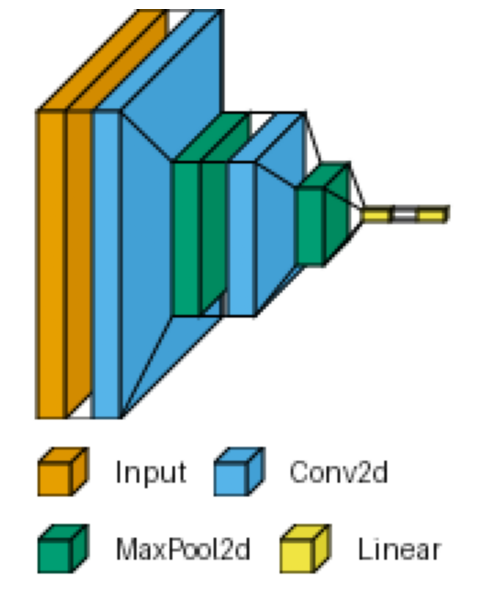

In [63]:
model_struct = visualize_model(SimpleCNN(), (1,1,28,28))

plt.figure(figsize=(6,8))
plt.imshow(model_struct)
plt.axis("off");

#### $8)$ 모델 생성 및 CPU 지정

위에 정의한 CNN 모델을 생성합시다. 이 모델이 학습되기 위해서는 CPU/GPU 사용 여부를 설정해야 합니다.

In [64]:
device = torch.device("cpu")

torch.manual_seed(seed)

model = SimpleCNN()
model = model.to(device)

print("Device:", device)
print(model)

Device: cpu
SimpleCNN(
  (conv1): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=784, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=10, bias=True)
)


모델이 학습할 파라미터 수를 확인해봅시다.

In [65]:
parameter_count = sum(
    parameter.numel()
    for parameter in model.parameters()
)

trainable_parameter_count = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print("Total parameters:", parameter_count)
print("Trainable parameters:", trainable_parameter_count)

Total parameters: 52138
Trainable parameters: 52138


#### $9)$ 순전파 기능 확인

실제 데이터를 학습하기 전에 임의의 입력(Dummy Input)을 모델에 전달하여 순전파(forward) 기능을 확인합시다.

In [66]:
dummy_input = torch.randn(1, 1, 28, 28)
dummy_output = model(dummy_input)

print("Input shape:", dummy_input.shape)
print("Output shape:", dummy_output.shape)

Input shape: torch.Size([1, 1, 28, 28])
Output shape: torch.Size([1, 10])


입력 데이터는 MNIST의 기본 규격인 28×28 크기의 흑백(단일 채널) 이미지이며, 순전파 연산 결과 10개의 클래스(정수 0~9)로 출력됩니다.

이번에는, Batch 하나를 불러와 순전파의 각 단계별 데이터의 크기를 확인해봅시다.

In [67]:
sample_images, sample_labels = next(
    iter(train_loader)
)

sample_images = sample_images.to(device)

with torch.no_grad():
    logits, features = model(
        sample_images,
        return_features=True,
    )

print("Input:", sample_images.shape)

for name, feature in features.items():
    print(f"{name}:", feature.shape)

print("Logits:", logits.shape)

Input: torch.Size([64, 1, 28, 28])
conv1: torch.Size([64, 8, 28, 28])
relu1: torch.Size([64, 8, 28, 28])
pool1: torch.Size([64, 8, 14, 14])
conv2: torch.Size([64, 16, 14, 14])
relu2: torch.Size([64, 16, 14, 14])
pool2: torch.Size([64, 16, 7, 7])
Logits: torch.Size([64, 10])


#### $10)$ Feature Map 확인

CNN 각 층의 Feature Map을 확인하기 위한 함수를 정의합니다.

In [68]:
def show_feature_maps(feature_tensor, title, max_maps=8, cmap="gray"):
    if feature_tensor.ndim != 4:
        raise ValueError("Feature Tensor는 [Batch, Channel, Height, Width] 형태여야 합니다.")

    feature_maps = feature_tensor[0].detach().cpu()

    channel_count = min(feature_maps.shape[0], max_maps)
    column_count = 4
    row_count = int(np.ceil(channel_count / column_count))

    plt.figure(figsize=(12, 3 * row_count))

    for channel_index in range(channel_count):
        plt.subplot(row_count, column_count, channel_index + 1)
        plt.imshow(feature_maps[channel_index], cmap=cmap)
        plt.title(f"Channel {channel_index}")
        plt.axis("off")
        plt.suptitle(title)

이제 입력 이미지 한 장을 선택하여 순전파를 적용해봅시다.

이미지 한 장만 선택하기에 Batch 차원이 없습니다. 그러므로 `unsqueeze(0)`를 사용하여 차원을 추가합니다.

In [69]:
image, label = test_dataset[0]

input_batch = image.unsqueeze(0).to(device)

print("Single image:", image.shape)
print("Batch image:", input_batch.shape)

Single image: torch.Size([1, 28, 28])
Batch image: torch.Size([1, 1, 28, 28])


순전파 실행:

In [70]:
model.eval()

with torch.no_grad():
    logits, features = model(
        input_batch,
        return_features=True,
    )

원본 이미지 출력:

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

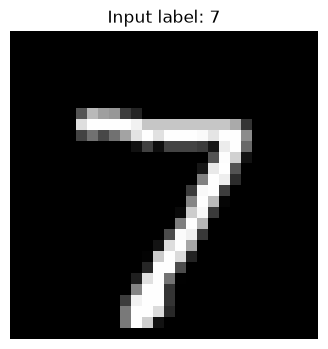

In [71]:
plt.figure(figsize=(4,4))

plt.imshow(image.squeeze(0), cmap="gray"), plt.title(f"Input label: {label}")
plt.axis("off")

첫 번째 Convolution 결과:

Channel 0: Conv min=0.252480, Conv max=1.411136, 
Channel 1: Conv min=-0.453152, Conv max=0.638269, 
Channel 2: Conv min=-1.015003, Conv max=-0.213439, 
Channel 3: Conv min=-0.737451, Conv max=0.117844, 
Channel 4: Conv min=-0.249831, Conv max=0.620810, 
Channel 5: Conv min=-0.404385, Conv max=0.325157, 
Channel 6: Conv min=-0.113948, Conv max=0.632331, 
Channel 7: Conv min=-0.035502, Conv max=0.571724, 


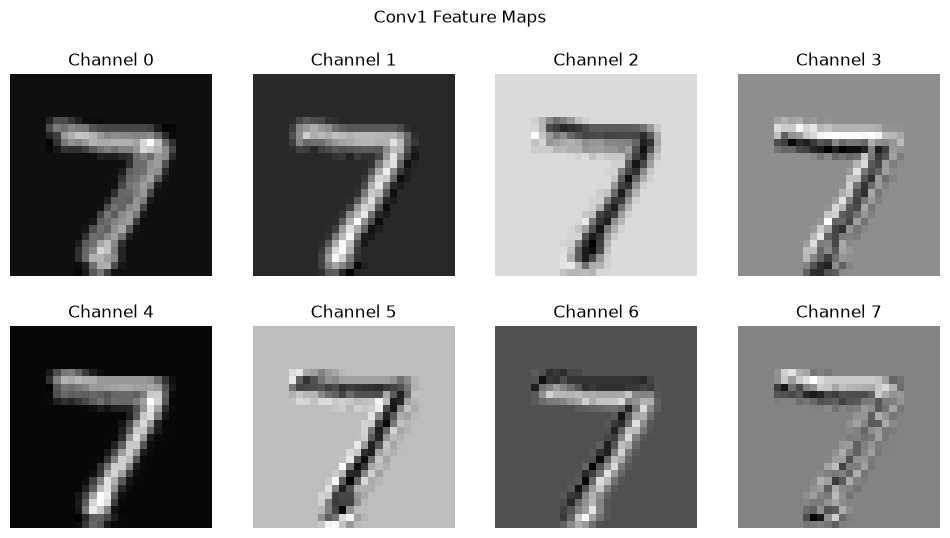

In [72]:
show_feature_maps(
    features["conv1"],
    title="Conv1 Feature Maps",
    max_maps=8,
)
for i in range(8):
    conv = features["conv1"][0, i]

    print(
        f"Channel {i}: "
        f"Conv min={conv.min().item():.6f}, "
        f"Conv max={conv.max().item():.6f}, "
        )

학습 전 모델에서 Feature Map을 출력하면 Filter가 무작위로 초기화되어 있기 때문에 의미 있는 특징이 명확하게 나타나지 않습니다.

학습 후에는 숫자 분류에 유용한 선, 방향, 경계 등에 반응하는 Feature Map이 나타납니다.

이번엔 ReLU까지 적용하여 확인해봅시다.

첫 번째 ReLU 결과:

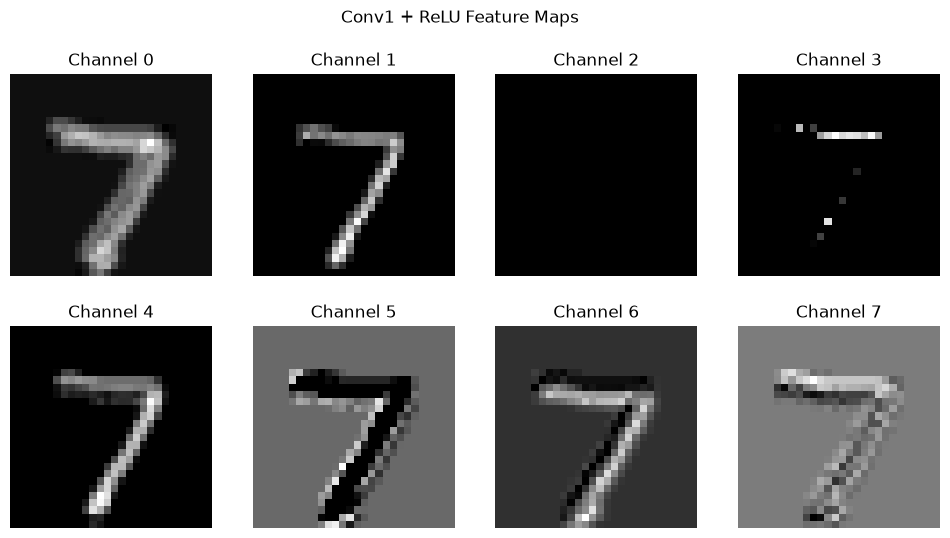

In [73]:
show_feature_maps(
    features["relu1"],
    title="Conv1 + ReLU Feature Maps",
    max_maps=8,
)

ReLU를 적용하면 음수 반응(원치 않는 특성)은 모두 0으로 처리됩니다. 여전히 학습되기 전이기에 원하는 특성을 추출하는 가중치(필터)가 없어 큰 의미를 찾기는 어렵습니다.

다음으로 Pooling을 적용해봅시다.

첫 번째 Pooling 결과:

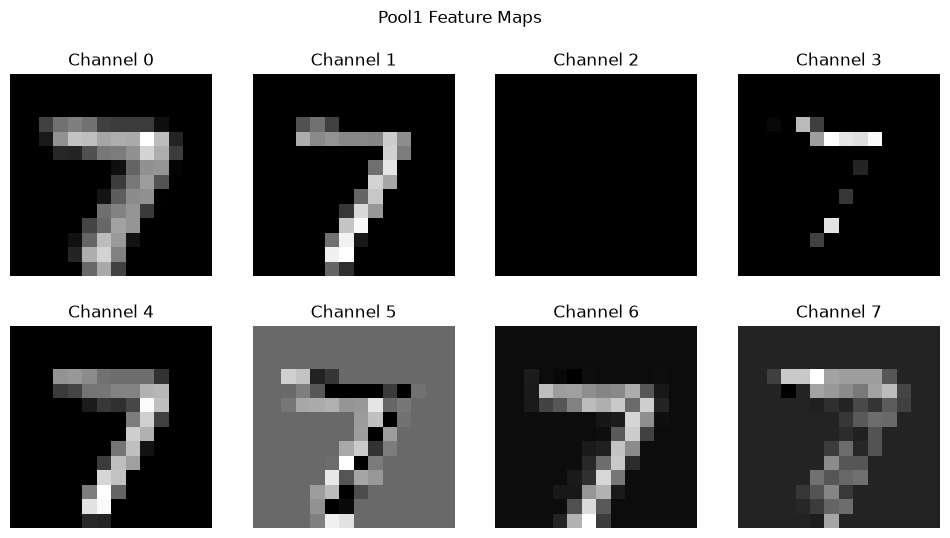

In [74]:
show_feature_maps(
    features["pool1"],
    title="Pool1 Feature Maps",
    max_maps=8,
)

이미지의 크기가 28x28에서 14x14로 줄어든 것을 확인할 수 있습니다.

두 번째 Convolution 결과:

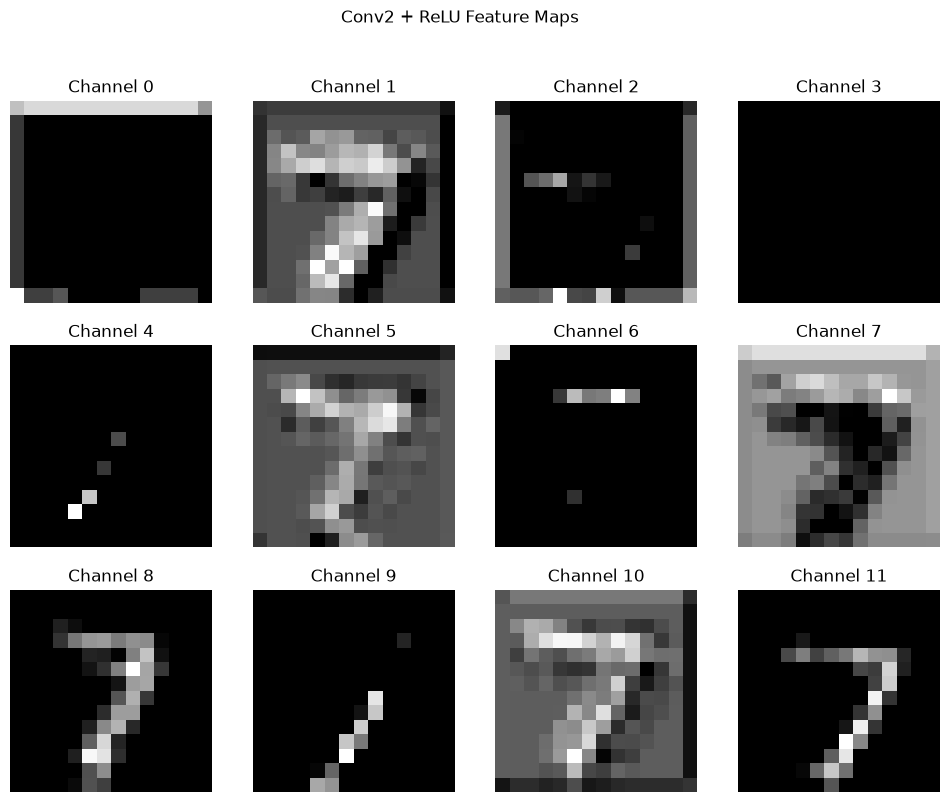

In [75]:
show_feature_maps(
    features["relu2"],
    title="Conv2 + ReLU Feature Maps",
    max_maps=12,
)

두 번째 Layer는 첫 번째 Layer에서 추출한 특징들을 조합합니다.

따라서 단순한 Edge보다 숫자의 획이나 모양 일부에 반응하는 형태가 나타날 수 있습니다.

두 번째 Pooling 결과:

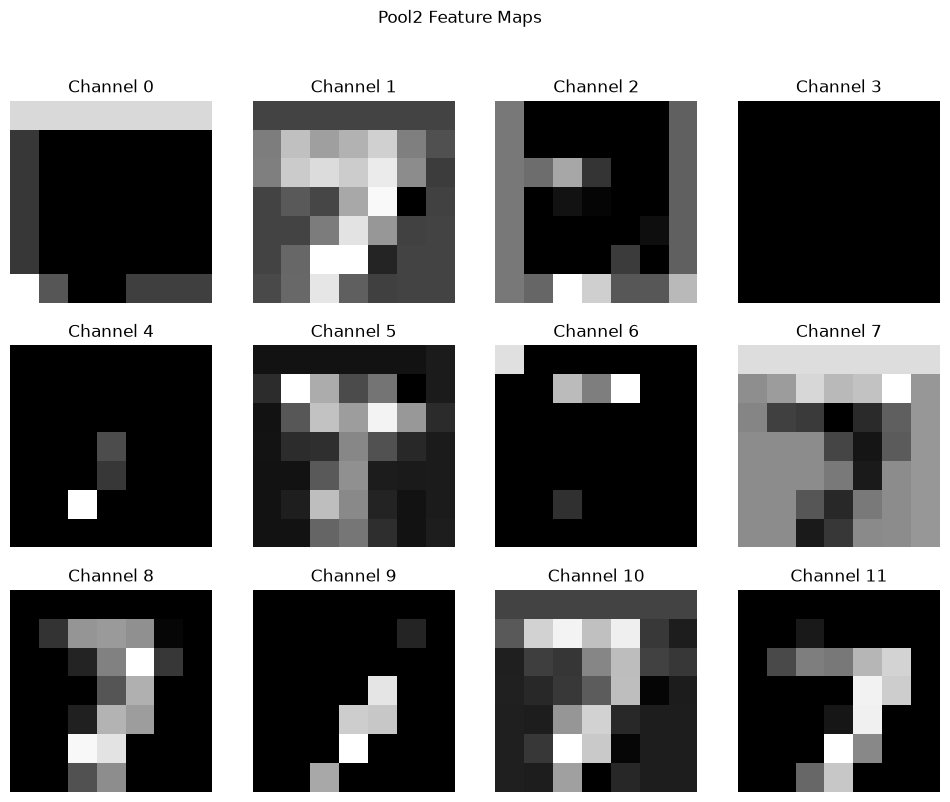

In [76]:
show_feature_maps(
    features["pool2"],
    title="Pool2 Feature Maps",
    max_maps=12,
)

최종 Feature Map 크기는 16×7×7 입니다.

이 특징들이 Flatten과 Fully Connected Layer로 전달됩니다.

#### $11)$ 가중치(필터) 확인

첫 번째 Convolution Layer의 가중치 크기를 확인합시다.

In [77]:
conv1_weights = model.conv1.weight.detach().cpu()
print(conv1_weights.shape)

torch.Size([8, 1, 3, 3])


3x3 필터 8개를 가중치로 가지고 있는 것을 확인할 수 있습니다.

필터들을 시각화해 봅시다.

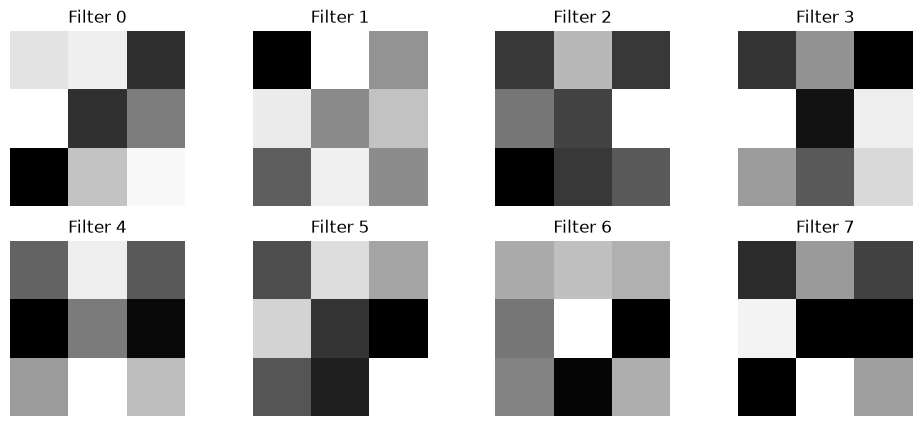

In [78]:
plt.figure(figsize=(12,5))

for filter_index in range(conv1_weights.shape[0]):
    plt.subplot(2, 4, filter_index + 1)
    plt.imshow(conv1_weights[filter_index, 0], cmap="gray")
    plt.title(f"Filter {filter_index}")
    plt.axis("off")

학습 전에는 무작위 Filter가 나타납니다.

학습 후 같은 코드를 다시 실행하면 가중치가 변경된 것을 확인할 수 있습니다.

#### $12)$ 손실 함수와 Optimizer 설정

MNIST는 10개 클래스 중 하나를 선택하는 다중 클래스 분류 문제이다. 해당 실습에서는 정답 분포와 예측 분포의 차이를 측정하여 다중 클래스를 분류하는 손실 함수인 Cross Entropy를 사용합니다.

In [79]:
criterion = nn.CrossEntropyLoss()

CrossEntropyLoss에는 모델의 원시 출력인 Logit을 직접 입력합니다. 그러므로 학습 코드에서 Cross Entropy 앞에 Softmax를 별도로 적용하여 입력하지 않습니다.

Optimizer는 역전파로 계산된 Gradient를 사용하여 CNN의 Filter, Bias, Fully Connected Weight 등을 수정합니다.

In [80]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
)

#### $13)$ CNN 모델 학습

CNN 모델 학습은 Batch 단위로 진행됩니다.

하나의 Batch 학습 순서는 다음과 같습니다.

1. 이미지와 Label을 CPU로 이동
2. 기존 Gradient 초기화
3. CNN 순전파
4. Loss 계산
5. CNN 역전파
6. Weight 업데이트

해당 과정을 함수로 정의합니다.

In [81]:
def train_one_epoch(model, data_loader, criterion, optimizer, device):
    # 모델을 학습 모드(training mode)로 변경
    model.train()

    # 결과를 누적하기 위한 변수
    total_loss = 0.0
    correct_count = 0
    sample_count = 0

    # 학습 데이터를 DataLoader(train_loader)의 Batch 단위로 불러와 학습 반복
    for images, labels in data_loader:
        # CPU로 이동
        images = images.to(device)
        labels = labels.to(device)

        # Gradient 초기화 (이전 Batch에서 계산한 Gradient를 제거)
        optimizer.zero_grad()

        # 순전파를 통해 원시 출력 저장 (클래스별 점수 10개)
        logits = model(images)

        # Loss 계산
        loss = criterion(logits, labels)
        # 역전파를 통한 Gradient 계산
        loss.backward()
        # Gradient를 사용하여 파라미터 수정
        optimizer.step()

        # Batch 한 개의 이미지 개수
        batch_size = images.size(0)

        # 결과 누적
        total_loss += loss.item() * batch_size                 # Loss 누적 (1개 batch의 평균 loss x batch 크기)
        predictions = logits.argmax(dim=1)                     # 가장 높은 점수를 가진 클래스를 선택
        correct_count += (predictions == labels).sum().item()  # 정답을 맞춘 개수 계산
        sample_count += batch_size                             # 전체 샘플 수 누적

    # 평균 Loss 및 Accuracy 계산
    average_loss = total_loss / sample_count
    accuracy = correct_count / sample_count

    return average_loss, accuracy

#### $14)$ CNN 모델 평가

모델 학습이 완료되었다면, 제대로 학습이 되었는지 테스트 데이터로 평가를 해야합니다.

평가(테스트) 과정에서는 가중치를 수정하지 않습니다.

학습된 모델을 평가하는 함수를 정의합시다.

In [82]:
def evaluate(model, data_loader, criterion, device):
    # 모델을 평가 모드(evaluation mode)로 변경
    model.eval()

    # 결과를 누적하기 위한 변수
    total_loss = 0.0
    correct_count = 0
    sample_count = 0

    # Gradient 계산을 비활성화 (파라미터 수정 비활성화)
    with torch.no_grad():
        # 평가 데이터를 DataLoader(test_loader)의 Batch 단위로 불러와 평가 반복
        for images, labels in data_loader:
            # CPU로 이동
            images = images.to(device)
            labels = labels.to(device)

            # 학습된 모델의 순전파를 통해 원시 출력 저장 (클래스별 점수 10개)
            logits = model(images)

            # Loss 계산 (역전파는 수행하지 않음)
            loss = criterion(logits, labels)

            # Batch 한 개의 이미지 개수
            batch_size = images.size(0)

            # 결과 누적
            total_loss += loss.item() * batch_size                 # Loss 누적 (1개 batch의 평균 loss x batch 크기)
            predictions = logits.argmax(dim=1)                     # 가장 높은 점수를 가진 클래스를 선택
            correct_count += (predictions == labels).sum().item()  # 정답을 맞춘 개수 계산
            sample_count += batch_size                             # 전체 샘플 수 누적

        # 평균 Loss 및 Accuracy 계산
        average_loss = total_loss / sample_count
        accuracy = correct_count / sample_count

        return average_loss, accuracy

#### $15)$ MNIST 숫자 손글씨 추론

지금까지 MNIST 손글씨 숫자 분류 모델을 추론하기 위한 전체 구성 요소를 단계적으로 구현했습니다.

진행한 과정은 다음과 같습니다.

- MNIST 데이터셋을 설치하고 학습 데이터와 테스트 데이터를 불러오기
- DataLoader를 생성하여 데이터를 batch 단위로 처리할 수 있도록 구성
- CNN 기반 분류 모델을 class 형태로 정의하고 Convolution, Pooling, Fully Connected Layer 설정
- 정의한 CNN 모델을 불러와 생성하고 연산 장치(device)를 CPU로 지정
- 모델 학습에 사용할 손실 함수와 optimizer 설정
- CNN 모델의 학습 과정을 수행하는 `train_one_epoch()` 함수 정의
- 학습된 모델의 성능을 평가하는 `evaluate()` 함수 정의

이번 단계에서는 앞에서 구현한 데이터 처리 과정, CNN 모델, loss 함수, optimizer, 학습 및 평가 함수를 연결하여 모델을 실제로 학습시키고, 테스트 데이터에 대한 성능을 확인한 뒤 새로운 손글씨 숫자를 예측합니다.

Epoch 1/3 | Train loss: 0.3137 | Train accuracy: 90.69% | Test loss: 0.1022 | Test accuracy: 96.81% | Time: 18.67s
Epoch 2/3 | Train loss: 0.0970 | Train accuracy: 97.03% | Test loss: 0.0649 | Test accuracy: 97.96% | Time: 18.83s
Epoch 3/3 | Train loss: 0.0687 | Train accuracy: 97.92% | Test loss: 0.0548 | Test accuracy: 98.25% | Time: 21.36s
Total CPU training time: 58.85s
True label: 7
Predicted label: 7
Confidence: 0.9998853206634521


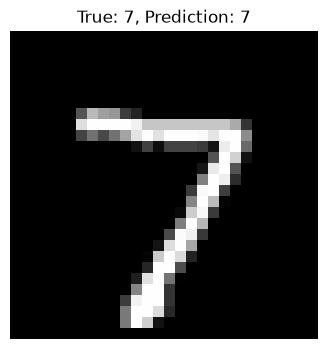

In [83]:
# 총 Epoch 정의 (전체 학습 데이터를 몇 번 반복해서 볼 것인지)
epochs = 3

# 학습 기록 저장 공간 준비
train_loss_history = []
train_accuracy_history = []
test_loss_history = []
test_accuracy_history = []

# 전체 학습 시간 측정 시작
training_start_time = time.perf_counter()

for epoch in range(epochs):
    # Epoch 시작 시간 저장
    epoch_start_time = time.perf_counter()

    # 모델 학습
    train_loss, train_accuracy = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device,
    )

    # 모델 평가
    test_loss, test_accuracy = evaluate(
        model,
        test_loader,
        criterion,
        device,
    )

    # 결과 저장 (학습 & 평가)
    train_loss_history.append(train_loss)
    train_accuracy_history.append(train_accuracy)
    test_loss_history.append(test_loss)
    test_accuracy_history.append(test_accuracy)

    # Epoch 소요 시간 계산
    epoch_time = time.perf_counter() - epoch_start_time

    # 현재 Epoch의 학습/평가 결과 출력
    print(
        f"Epoch {epoch + 1}/{epochs} | "
        f"Train loss: {train_loss:.4f} | "
        f"Train accuracy: "
        f"{train_accuracy * 100:.2f}% | "
        f"Test loss: {test_loss:.4f} | "
        f"Test accuracy: "
        f"{test_accuracy * 100:.2f}% | "
        f"Time: {epoch_time:.2f}s"
    )

# 전체 학습 시간 계산 및 출력
total_training_time = time.perf_counter() - training_start_time
print(f"Total CPU training time: {total_training_time:.2f}s")

# 학습된 모델로 이미지 하나 테스트
image, true_label = test_dataset[0]          # 테스트할 이미지(image)와 정답(label)
input_batch = image.unsqueeze(0).to(device)  # Batch 차원 추가(unsqueeze)하여 입력 Batch로 저장 (이미지 1장)

# 모델을 평가 모드(evaluation mode)로 변경
model.eval()

# Gradient 계산을 비활성화 (파라미터 수정 비활성화)
with torch.no_grad():
    logits = model(input_batch)                           # 학습된 모델의 순전파를 통해 원시 출력 저장 (클래스별 점수 10개)
    probabilities = torch.softmax(logits, dim=1)          # 원시 점수에 softmax 함수 적용 (클래스별 확률 계산)
    predicted_label = probabilities.argmax(dim=1).item()  # 정답 예측

# 결과 출력 (정답, 예측, confidence)
print("True label:", true_label)
print("Predicted label:", predicted_label)
print("Confidence:", probabilities[0, predicted_label].item())

# 결과 이미지 출력
plt.figure(figsize=(4,4))
plt.imshow(image.squeeze(0), cmap="gray")
plt.title(f"True: {true_label}, " f"Prediction: {predicted_label}")
plt.axis("off")
plt.show()

이제 여러 장의 손글씨 숫자를 추론해 확인해봅시다.

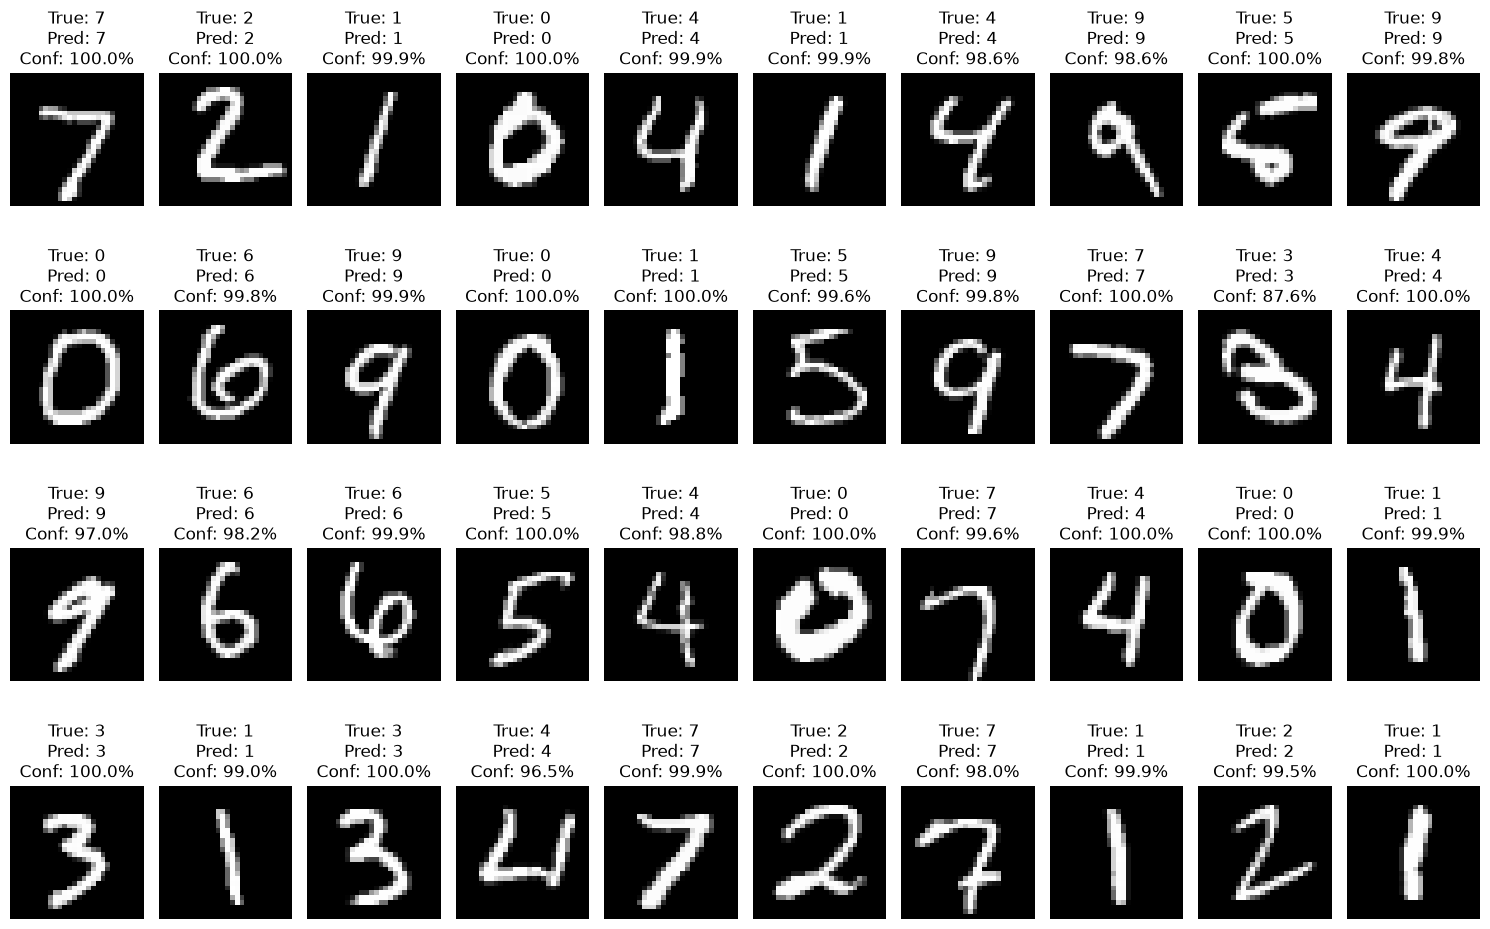

In [84]:
plt.figure(figsize=(15,10))

num_images = 40

model.eval()

with torch.no_grad():
    for i in range(num_images):
        image, true_label = test_dataset[i]
        input_batch = image.unsqueeze(0).to(device)

        logits = model(input_batch)
        probabilities = torch.softmax(logits, dim=1)
        predicted_label = probabilities.argmax(dim=1).item()
        confidence = probabilities[0, predicted_label].item()

        plt.subplot(4, 10, i+1)
        plt.imshow(image.squeeze(0), cmap="gray")
        plt.title(
            f"True: {true_label}\n"
            f"Pred: {predicted_label}\n"
            f"Conf: {confidence*100:.1f}%"
        )
        plt.axis("off")

plt.tight_layout()
plt.show()

#### $16)$ 모델 성능 확인

위 과정에서, 학습이 진행됨에 따라 Epoch별 학습 및 평가의 Loss와 Accuracy를 리스트에 저장했습니다.

해당 지표들을 Epoch별 그래프로 시각화하여 확인해봅시다.

우선 Loss 그래프입니다.

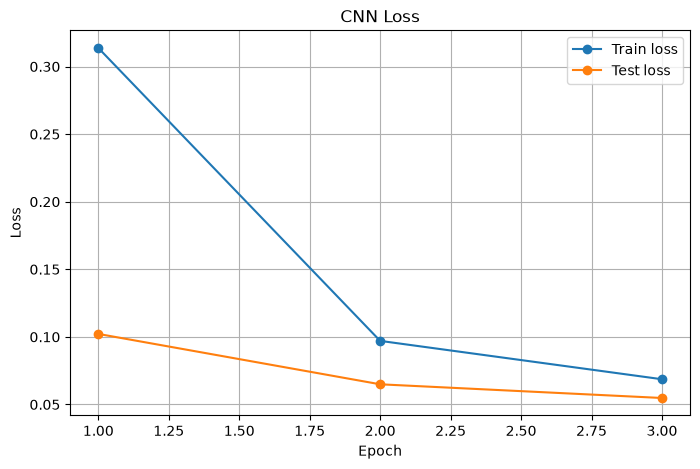

In [85]:
# TODO: plt.plot(x축_데이터, y축_데이터, marker="o", label="데이터_이름")을 사용하여 그래프 생성
plt.figure(figsize=(8,5))

# TODO: train_loss_history 그래프 생성
# plt.plot(...)
# TODO: test_loss_history 그래프 생성
# plt.plot(...)

epoch_axis = range(1, epochs + 1)

plt.plot(
    epoch_axis,
    train_loss_history,
    marker="o",
    label="Train loss",
)

plt.plot(
    epoch_axis,
    test_loss_history,
    marker="o",
    label="Test loss",
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Loss")
plt.grid()
plt.legend()
plt.show()

다음은 Accuracy 그래프입니다.

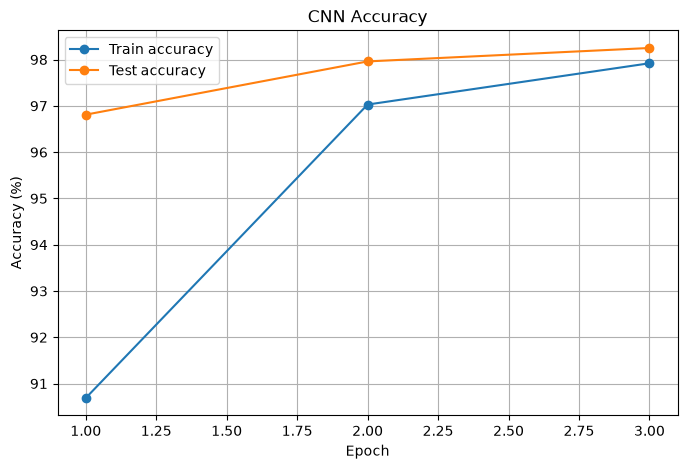

In [86]:
# TODO: plt.plot(x축_데이터, y축_데이터, marker="o", label="데이터_이름")을 사용하여 그래프 생성
plt.figure(figsize=(8,5))

# TODO: train_accuracy_history 그래프 생성 (백분율)
# plt.plot(...)
# TODO: test_accuracy_history 그래프 생성 (백분율)
# plt.plot(...)

plt.plot(
    epoch_axis,
    np.array(train_accuracy_history) * 100,
    marker="o",
    label="Train accuracy",
)

plt.plot(
    epoch_axis,
    np.array(test_accuracy_history) * 100,
    marker="o",
    label="Test accuracy",
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("CNN Accuracy")
plt.grid()
plt.legend()
plt.show()

#### $17)$ 학습된 모델의 Feature Map 확인

앞선 과정에서 모델 학습이 완료되었으니, 이제 각 층(layer)의 Feature Map을 다시 확인해봅시다. 이미 `show_feature_maps()` 함수를 위에서 정의했으니 활용하면 됩니다.

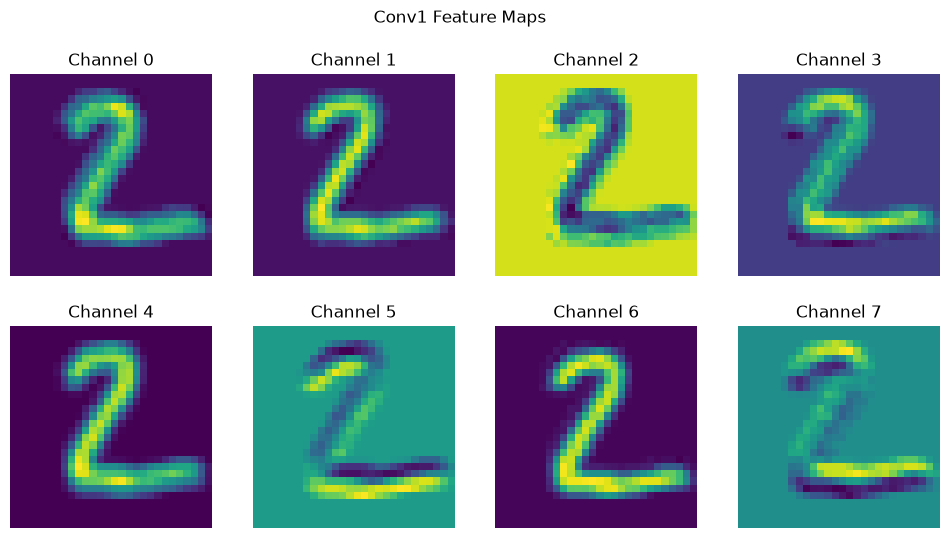

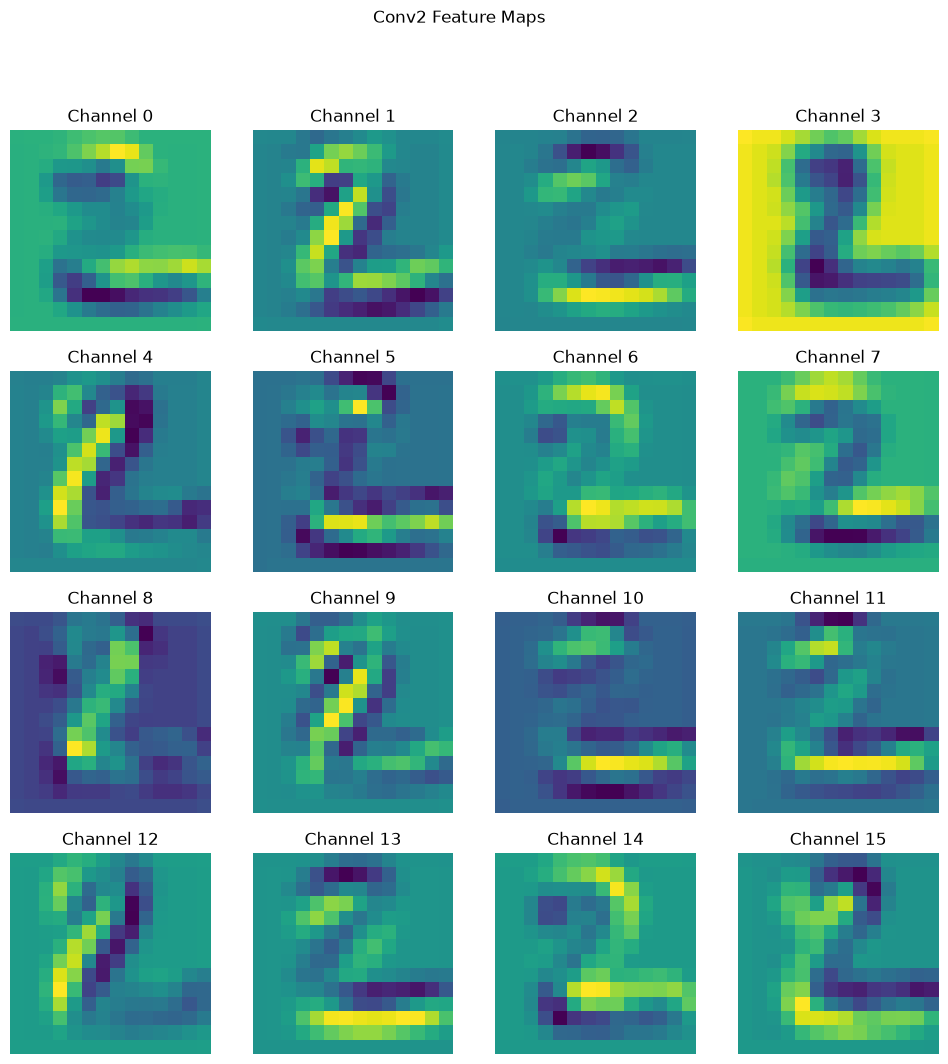

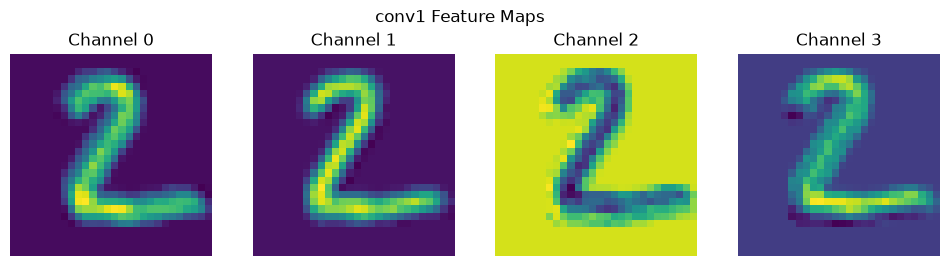

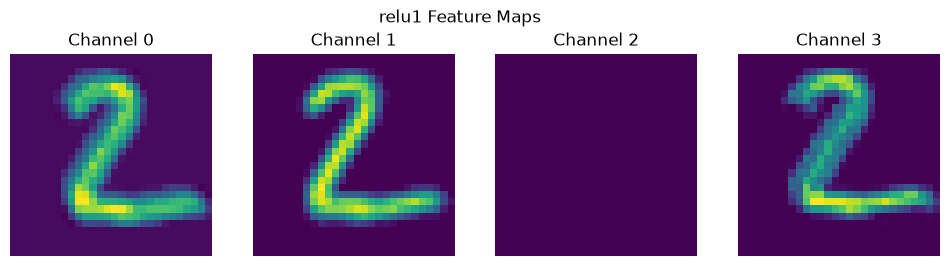

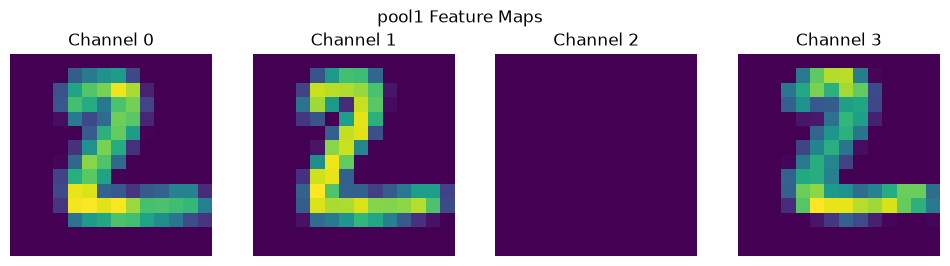

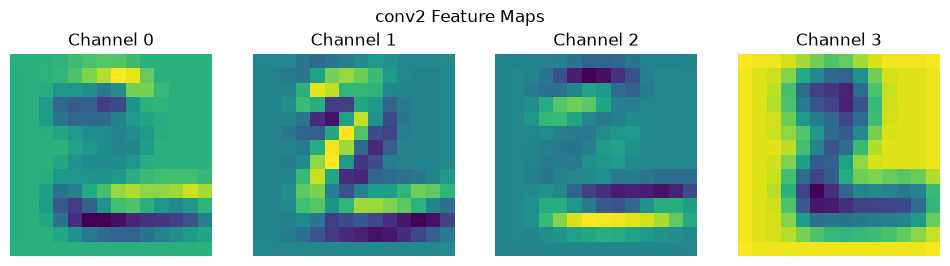

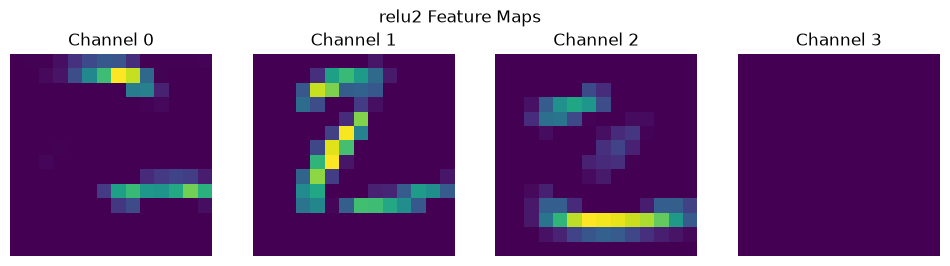

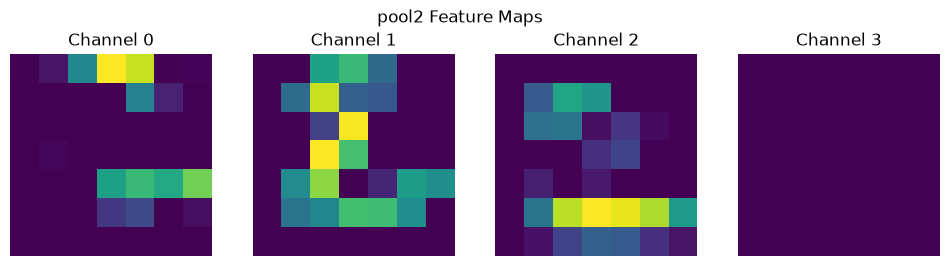

In [87]:
# TODO: CNN 각 층의 Feature Map 시각화
# TODO: 이미지 선택
# TODO: 역전파(파라미터 수정) 없이 순전파 수행
# TODO: Conv1 Feature Maps 8개 시각화
# TODO: Conv2 Feature Maps 16개 시각화
# TODO: 6개 Layer별 대표 Feature Map 4개씩 비교
# TODO: cmap="viridis" 사용
image, true_label = test_dataset[1]
input_batch = image.unsqueeze(0).to(device)

model.eval()

with torch.no_grad():
    logits, features = model(
        input_batch,
        return_features=True
    )

# Conv1 Feature Maps
show_feature_maps(
    features["conv1"],
    "Conv1 Feature Maps",
    max_maps=8,
    cmap="viridis",
)


# Conv2 Feature Maps
show_feature_maps(
    features["conv2"],
    "Conv2 Feature Maps",
    max_maps=16,
    cmap="viridis",
)


# Layer별 대표 Feature Map 비교
layer_names = [
    "conv1",
    "relu1",
    "pool1",
    "conv2",
    "relu2",
    "pool2"
]

for name in layer_names:
    show_feature_maps(
        features[name],
        f"{name} Feature Maps",
        max_maps=4,
        cmap="viridis",
    )

#### $18)$ 모델 저장 및 불러오기

학습이 완료된 모델을 추후에 사용하기 위해 저장하여 불러올 수 있습니다. 이를 통해 오래 걸리는 학습 과정을 반복하지 않아도 됩니다.

모델을 저장하고 재사용한다는 것은 결국 학습된 가중치를 보존한다는 의미입니다.

모델 저장:

In [88]:
torch.save(
    model.state_dict(),
    "src/models/MNIST/MNIST_CNN.pth",
)

모델 불러오기:

In [89]:
loaded_model = SimpleCNN()

state_dict = torch.load(
    "src/models/MNIST/MNIST_CNN.pth",
    map_location="cpu",
    weights_only=True,
)

loaded_model.load_state_dict(state_dict)
loaded_model.to(device)
loaded_model.eval()

SimpleCNN(
  (conv1): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=784, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=10, bias=True)
)

---

---
---

<br><br><div style="text-align: right; color: gray; font-style: italic;">
© 2026, 김규래 (Kyu Rae Kim), All rights reserved.&emsp;<br><br>
This material is provided solely for the intended instructional purpose.&emsp;<br>
Redistribution, reproduction, modification, adaptation, or reuse of this material in any form without prior written permission from the copyright holder is prohibited.&emsp;
</div>